### import library

In [1]:
import pandas as pd
import numpy as np
import os
import glob
from scipy import stats
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
import seaborn as sns
import matplotlib.pyplot as plt
import joblib 
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image, display
import pydotplus
from sklearn import tree
import m2cgen as m2c


### Task 1: Data Collection 
#### import collected data 

In [2]:
INPUT_FILE_PATH = "C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities/brisk_waling_abha_new_20260220_214337.csv"
DATA_DIR = "C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities"

CHANNELS = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

In [28]:
df = pd.read_csv(INPUT_FILE_PATH)

print(df.head())

      timestamp        ax        ay        az        gx         gy         gz  \
0  1.771604e+09  0.553711 -0.848389 -0.292480  90.75926 -92.956520  152.34380   
1  1.771604e+09  0.435791 -0.815308 -0.251465  87.28026 -66.711440  126.28172   
2  1.771604e+09  0.422241 -0.833496 -0.253296  81.05466 -30.944820  101.74560   
3  1.771604e+09  0.466797 -0.861938 -0.302124  69.45802   5.310058   84.96092   
4  1.771604e+09  0.512940 -0.849610 -0.361206  55.78612  35.522460   78.00294   

                activity  
0  brisk_waling_abha_new  
1  brisk_waling_abha_new  
2  brisk_waling_abha_new  
3  brisk_waling_abha_new  
4  brisk_waling_abha_new  


In [3]:
print(f"Checking directory: {DATA_DIR}")

if os.path.exists(DATA_DIR):
    print("Directory found! Listing files:\n")
    
    files = [f for f in os.listdir(DATA_DIR) if f.endswith('.csv')]
    
    if len(files) > 0:
        for i, f in enumerate(files):
            print(f"[{i}] {f}")
            
        print("\nACTION: Copy one of the filenames above and update 'INPUT_FILE_PATH'.")
    else:
        print("WARNING: Directory exists but contains NO .csv files.")
else:
    print("ERROR: The folder path itself is incorrect. Please check 'DATA_DIR'.")

Checking directory: C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities
Directory found! Listing files:

[0] brisk_waling_abha_new_20260220_214337.csv
[1] cycling_20260125_155502.csv
[2] eating_spoon_20260125_173356.csv
[3] full_processed_dataset.csv
[4] jogging_20260125_181023.csv
[5] phone_interaction_1_20260201_005353.csv
[6] pick_place_1_20260131_114737.csv
[7] sitting_1_20260131_112629.csv
[8] sit_stand_sit_20260125_182628.csv
[9] stair_down_20260125_181616.csv
[10] stair_up_20260125_182012.csv
[11] standing_1_20260201_001151.csv
[12] walking_abha_new_20260220_213943.csv

ACTION: Copy one of the filenames above and update 'INPUT_FILE_PATH'.


Found 13 files in C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities...
Plotting brisk_waling_abha_new_20260220_214337.csv...


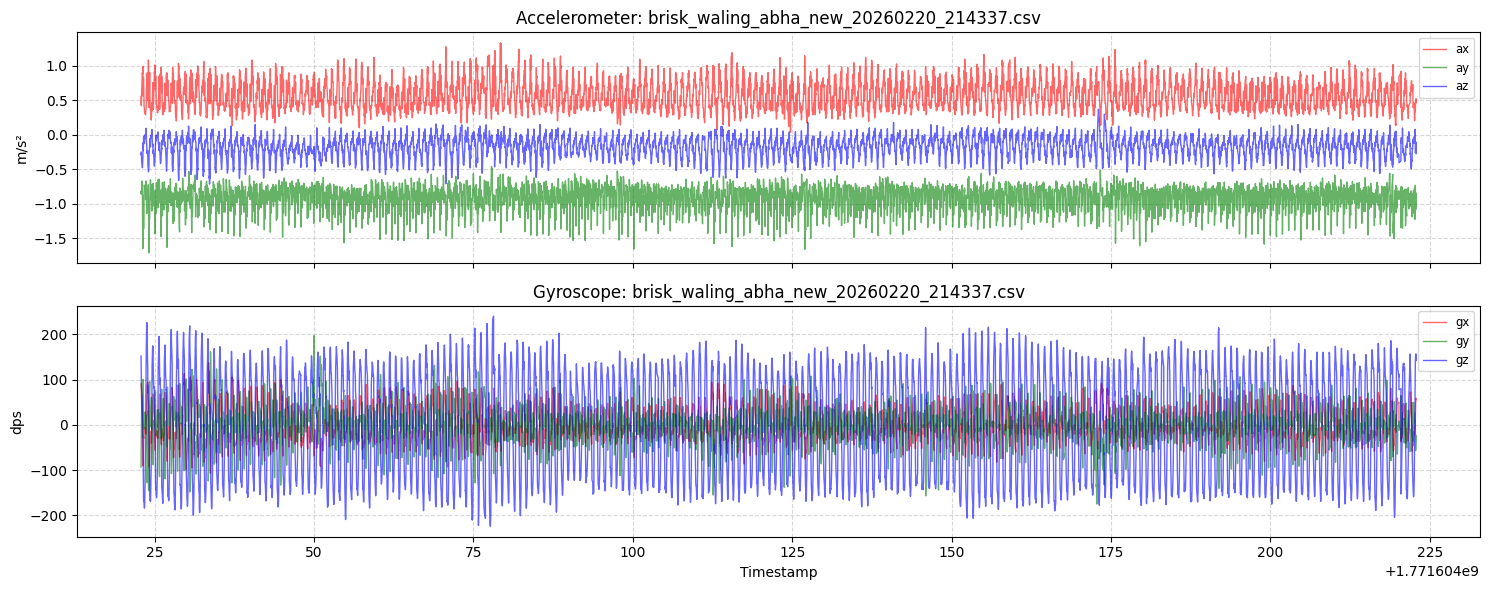

--------------------------------------------------
Plotting cycling_20260125_155502.csv...


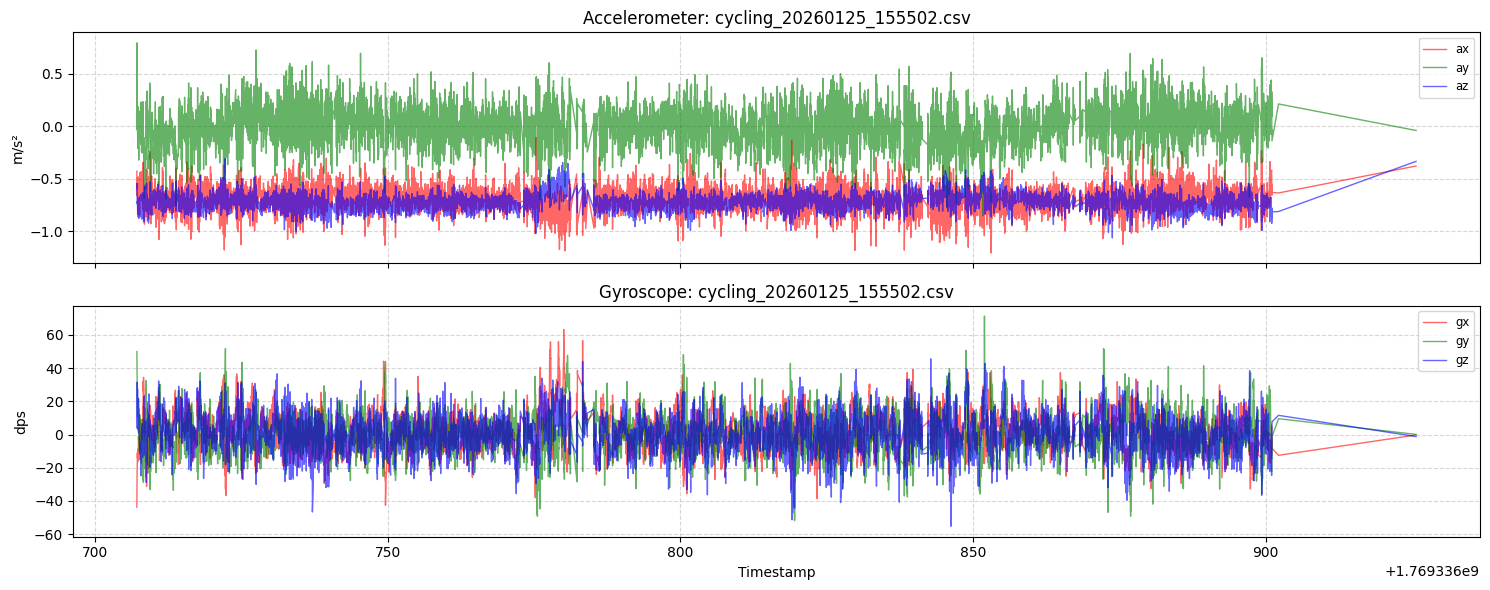

--------------------------------------------------
Plotting eating_spoon_20260125_173356.csv...


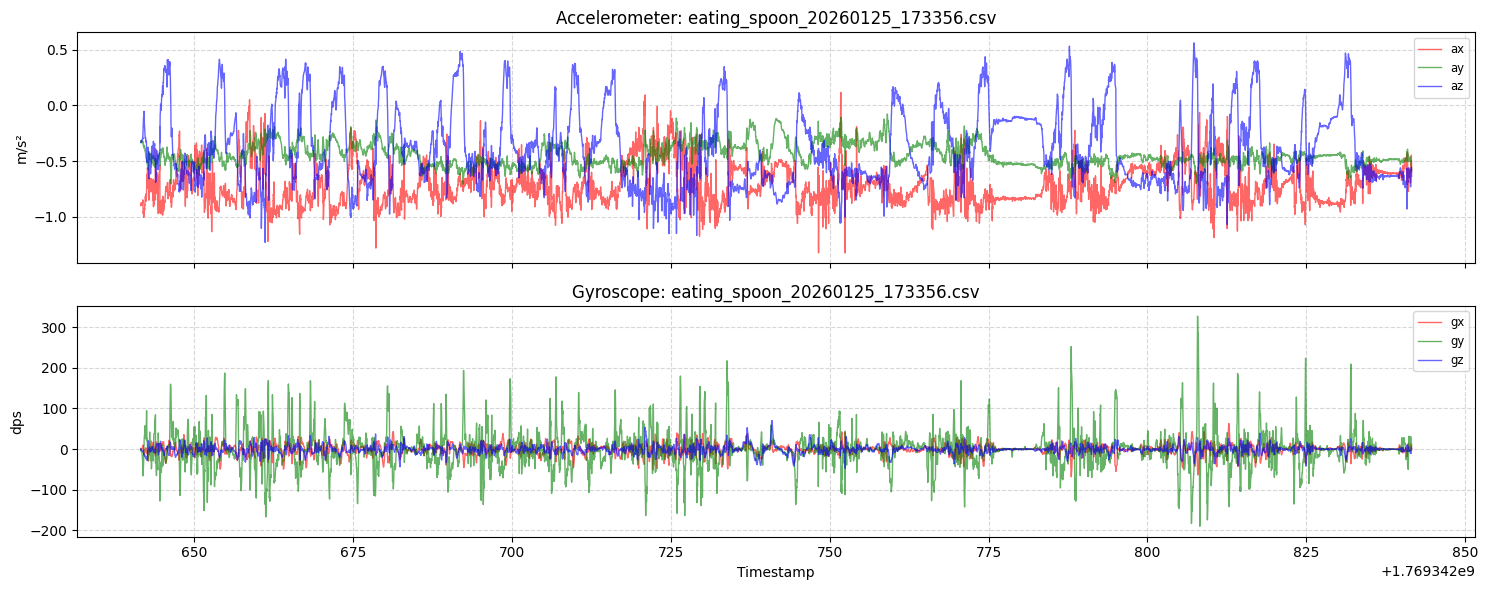

--------------------------------------------------
Plotting jogging_20260125_181023.csv...


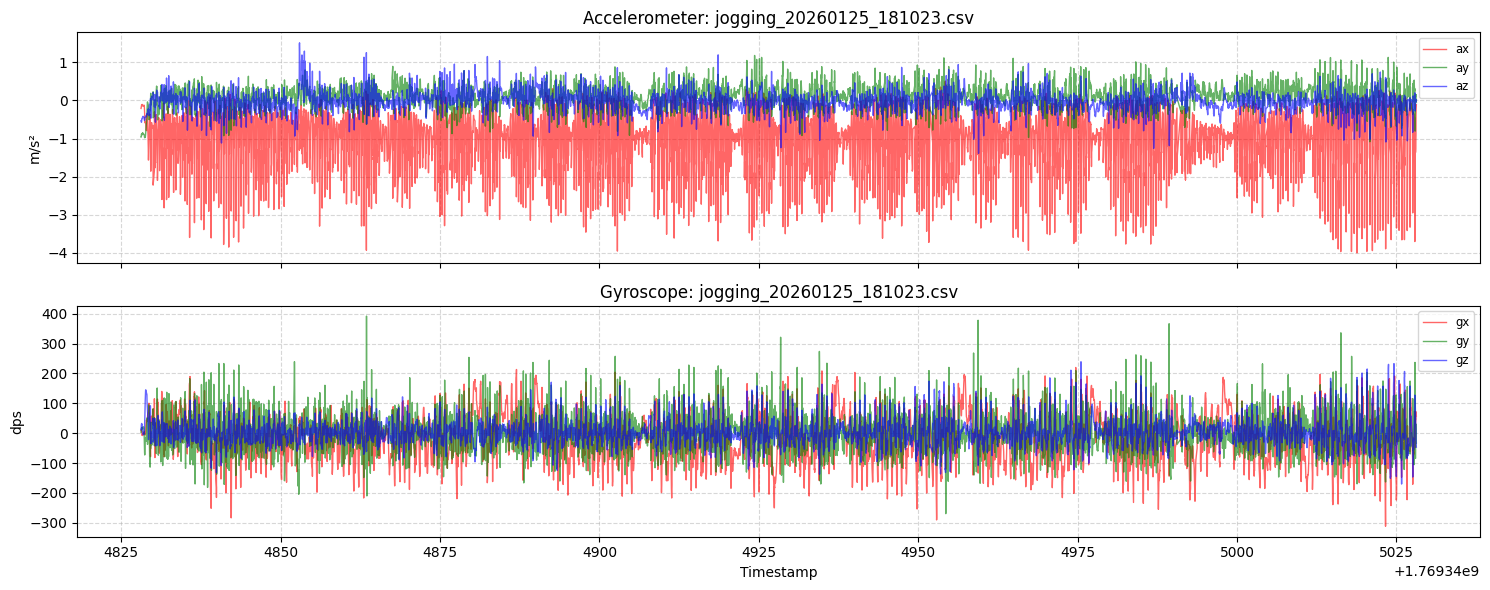

--------------------------------------------------
Plotting phone_interaction_1_20260201_005353.csv...


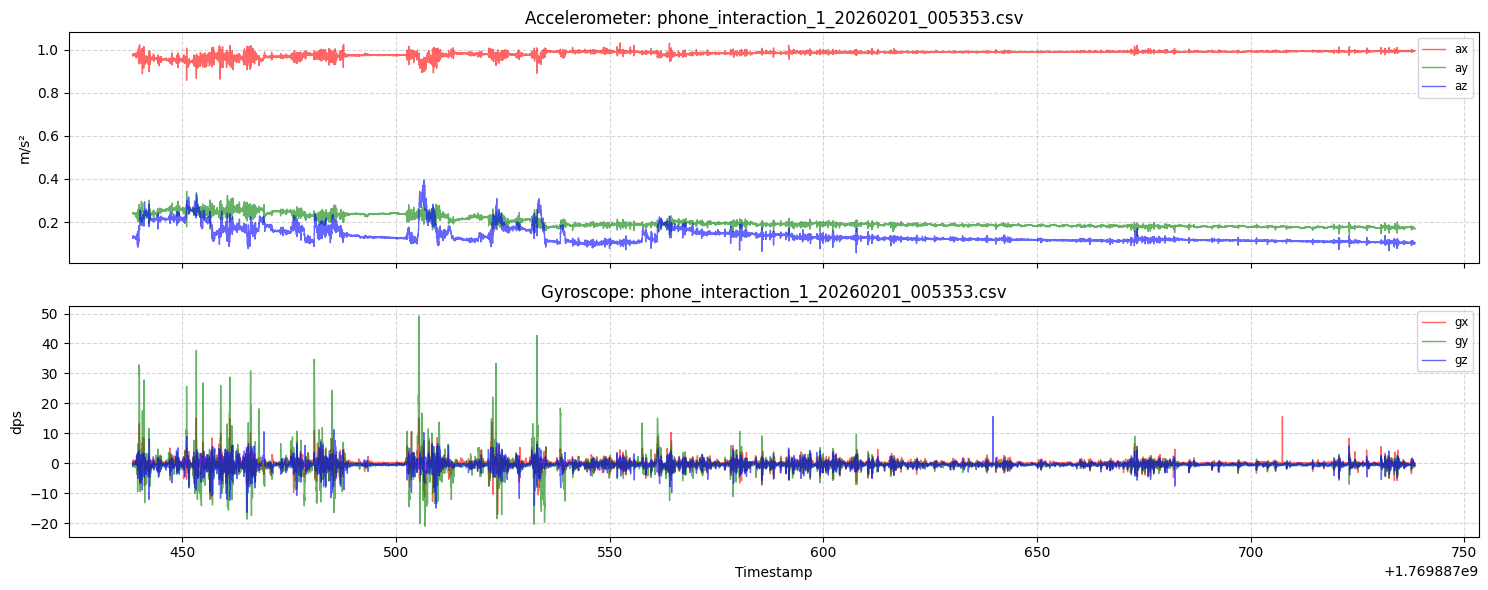

--------------------------------------------------
Plotting pick_place_1_20260131_114737.csv...


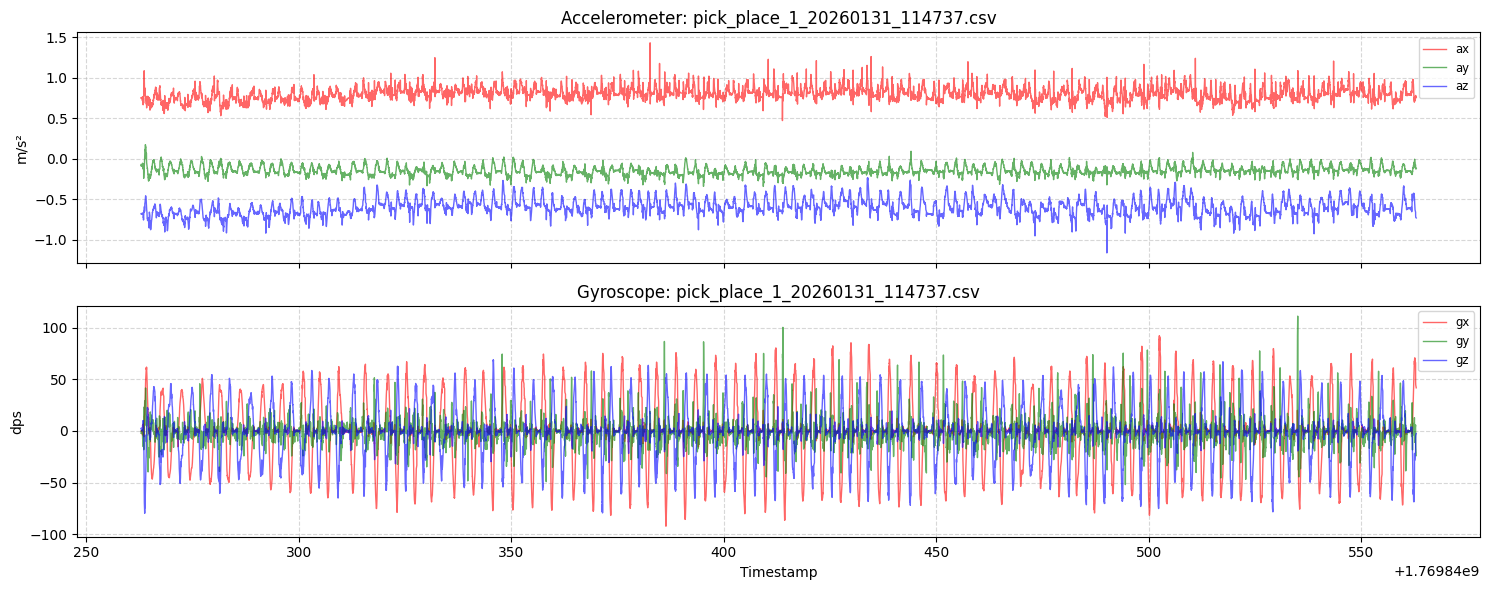

--------------------------------------------------
Plotting sitting_1_20260131_112629.csv...


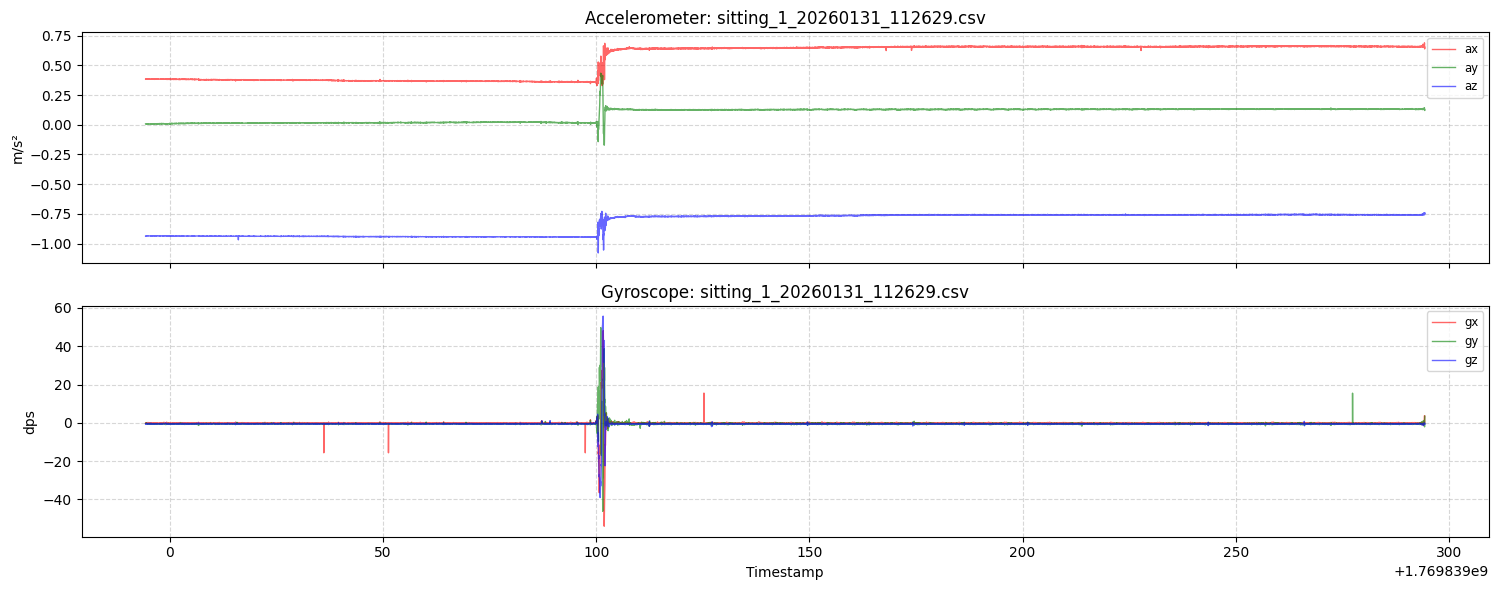

--------------------------------------------------
Plotting sit_stand_sit_20260125_182628.csv...


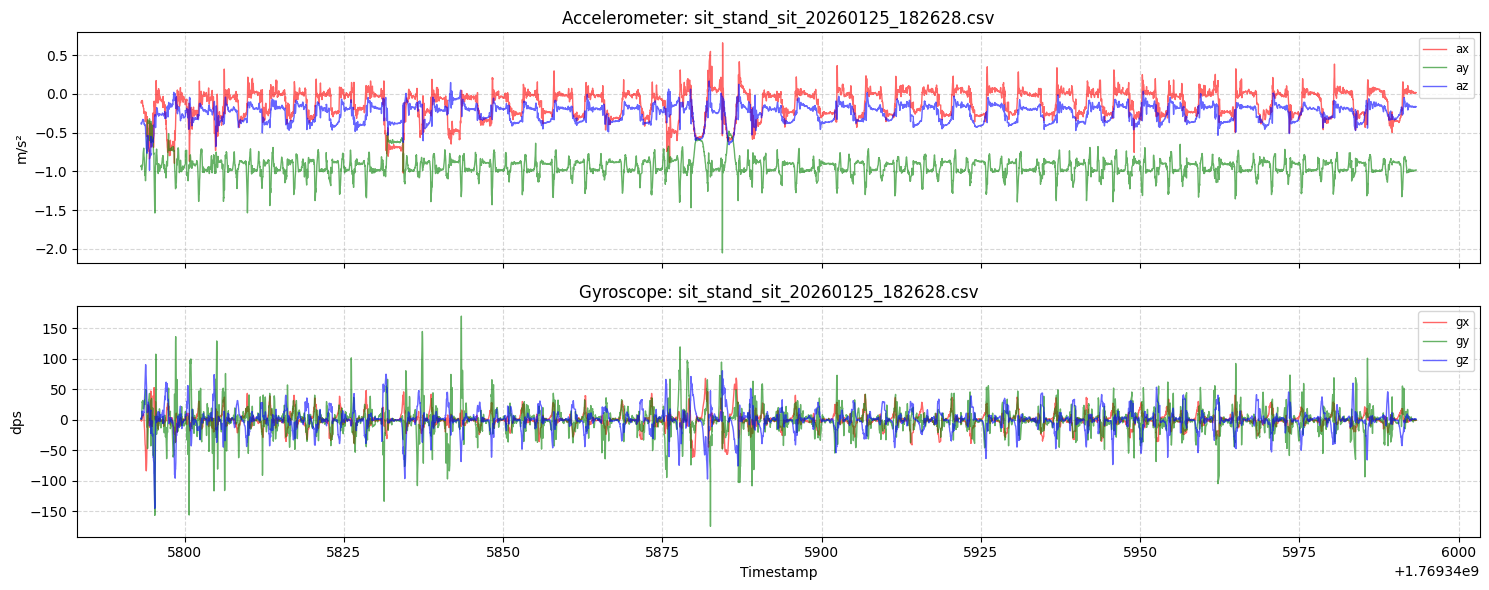

--------------------------------------------------
Plotting stair_down_20260125_181616.csv...


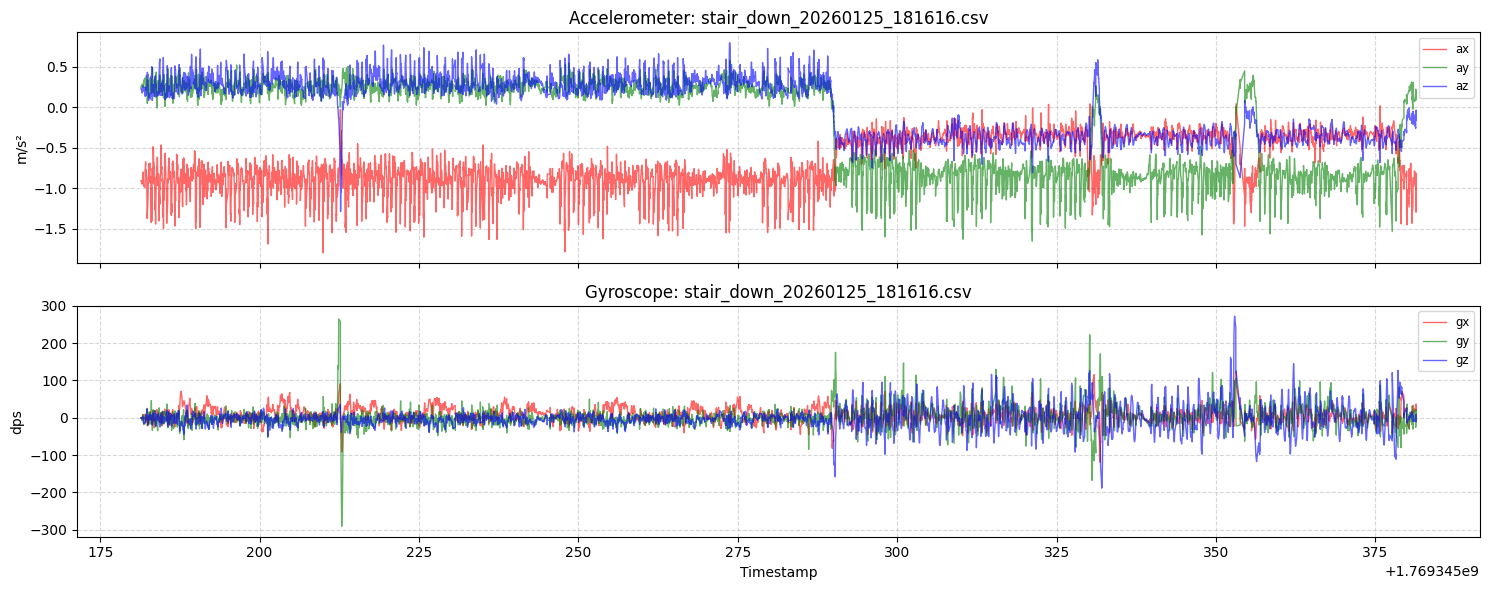

--------------------------------------------------
Plotting stair_up_20260125_182012.csv...


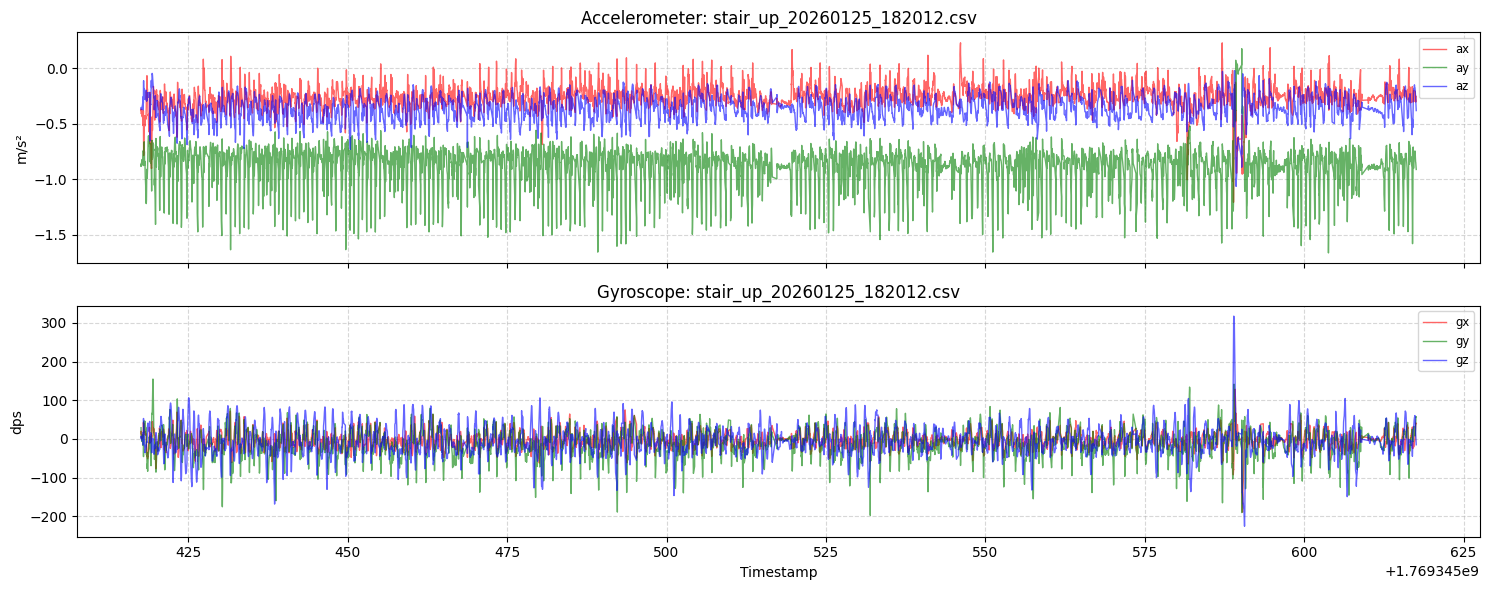

--------------------------------------------------
Plotting standing_1_20260201_001151.csv...


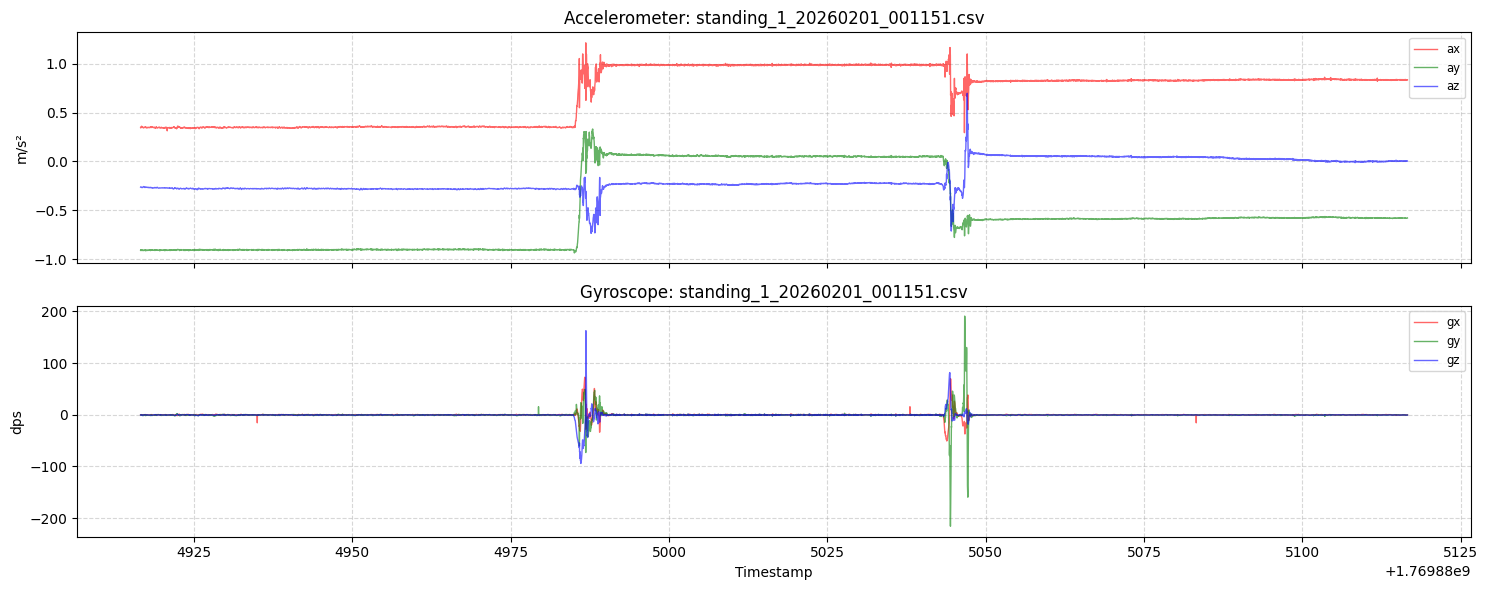

--------------------------------------------------
Plotting walking_abha_new_20260220_213943.csv...


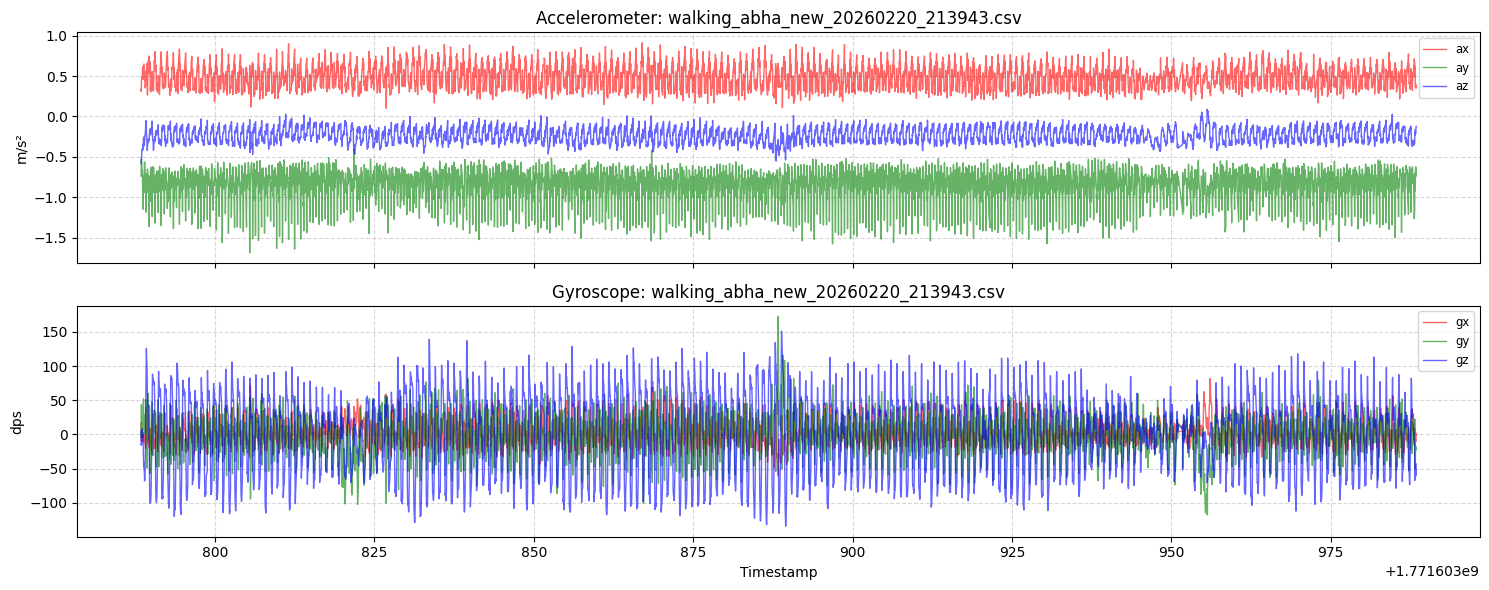

--------------------------------------------------


In [4]:
def plot_all_files(directory):

    all_files = glob.glob(os.path.join(directory, "*.csv"))
    
    print(f"Found {len(all_files)} files in {directory}...")
    
    for filepath in all_files:
        filename = os.path.basename(filepath)
        
        if "processed" in filename.lower():
            continue
            
        try:
            df = pd.read_csv(filepath)
            
            if df.empty:
                print(f"Skipping empty file: {filename}")
                continue
                
            df.columns = df.columns.str.strip().str.lower()
            
            if 'ax' not in df.columns:
                print(f"Skipping {filename} (No 'ax' column found)")
                continue
                
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            continue

        print(f"Plotting {filename}...")
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
        
        if 'timestamp' in df.columns:
            x_axis = df['timestamp']
            x_label = "Timestamp"
        else:
            x_axis = df.index
            x_label = "Sample Index"

        ax1.plot(x_axis, df['ax'], label='ax', color='r', alpha=0.6, linewidth=1)
        ax1.plot(x_axis, df['ay'], label='ay', color='g', alpha=0.6, linewidth=1)
        ax1.plot(x_axis, df['az'], label='az', color='b', alpha=0.6, linewidth=1)
        ax1.set_title(f'Accelerometer: {filename}')
        ax1.set_ylabel('m/s²')
        ax1.legend(loc='upper right', fontsize='small')
        ax1.grid(True, linestyle='--', alpha=0.5)

        if 'gx' in df.columns:
            ax2.plot(x_axis, df['gx'], label='gx', color='r', alpha=0.6, linewidth=1)
            ax2.plot(x_axis, df['gy'], label='gy', color='g', alpha=0.6, linewidth=1)
            ax2.plot(x_axis, df['gz'], label='gz', color='b', alpha=0.6, linewidth=1)
            ax2.set_title(f'Gyroscope: {filename}')
            ax2.set_ylabel('dps')
            ax2.legend(loc='upper right', fontsize='small')
            ax2.grid(True, linestyle='--', alpha=0.5)
        
        ax2.set_xlabel(x_label)
        
        plt.tight_layout()
        plt.show() # Display plot immediately
        print("-" * 50)

plot_all_files(DATA_DIR)

Found 13 files in C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities...
Generating Box Plot for: brisk_waling_abha_new_20260220_214337.csv


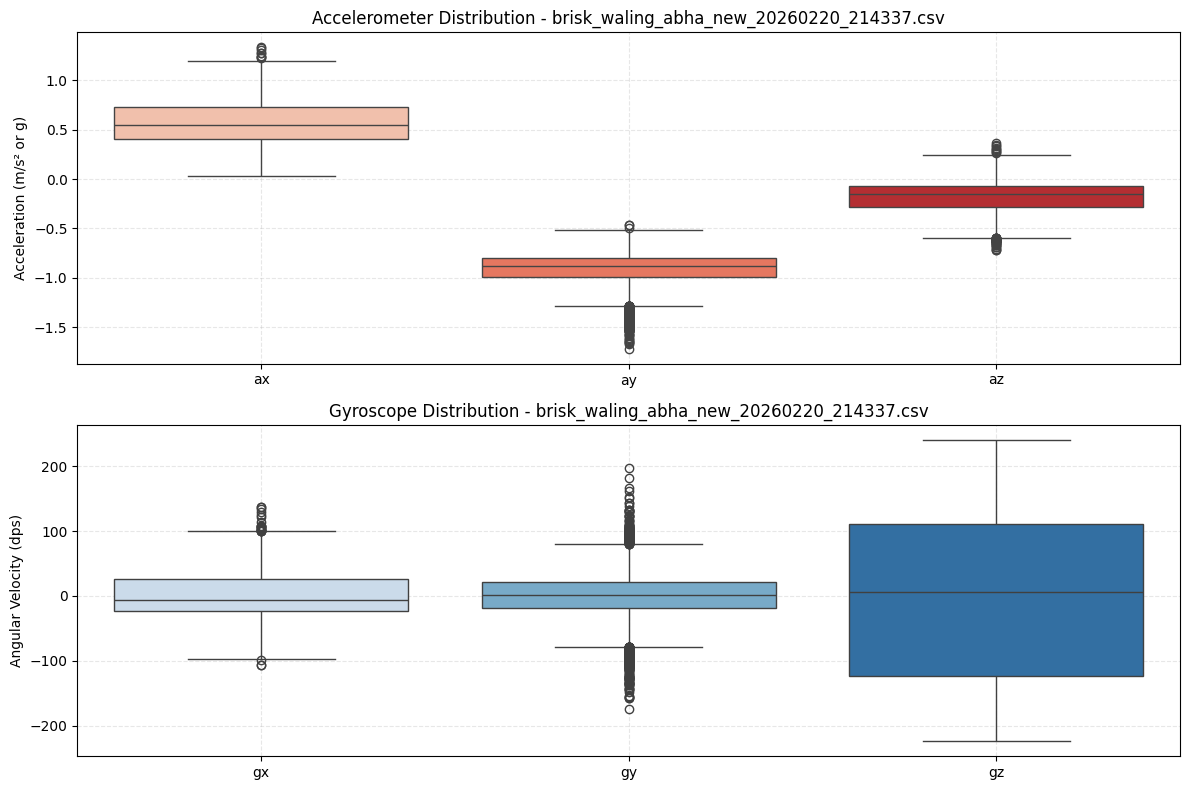

--------------------------------------------------
Generating Box Plot for: cycling_20260125_155502.csv


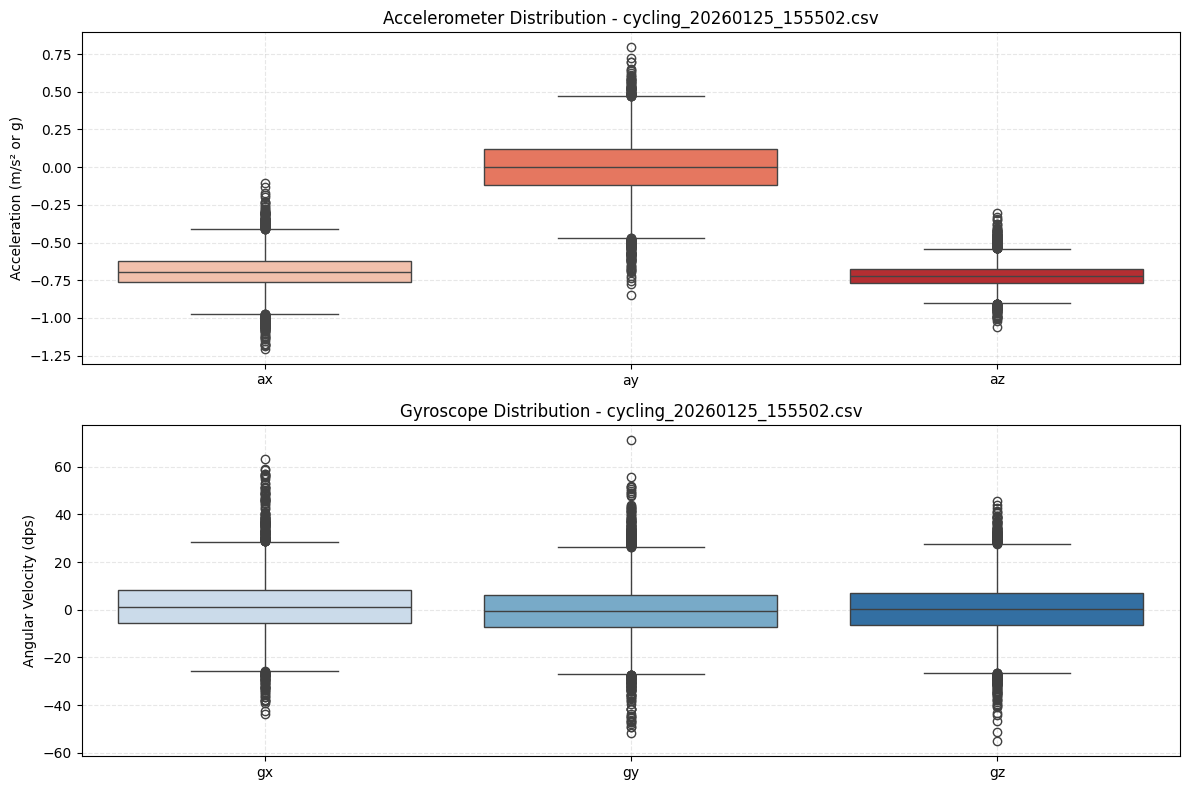

--------------------------------------------------
Generating Box Plot for: eating_spoon_20260125_173356.csv


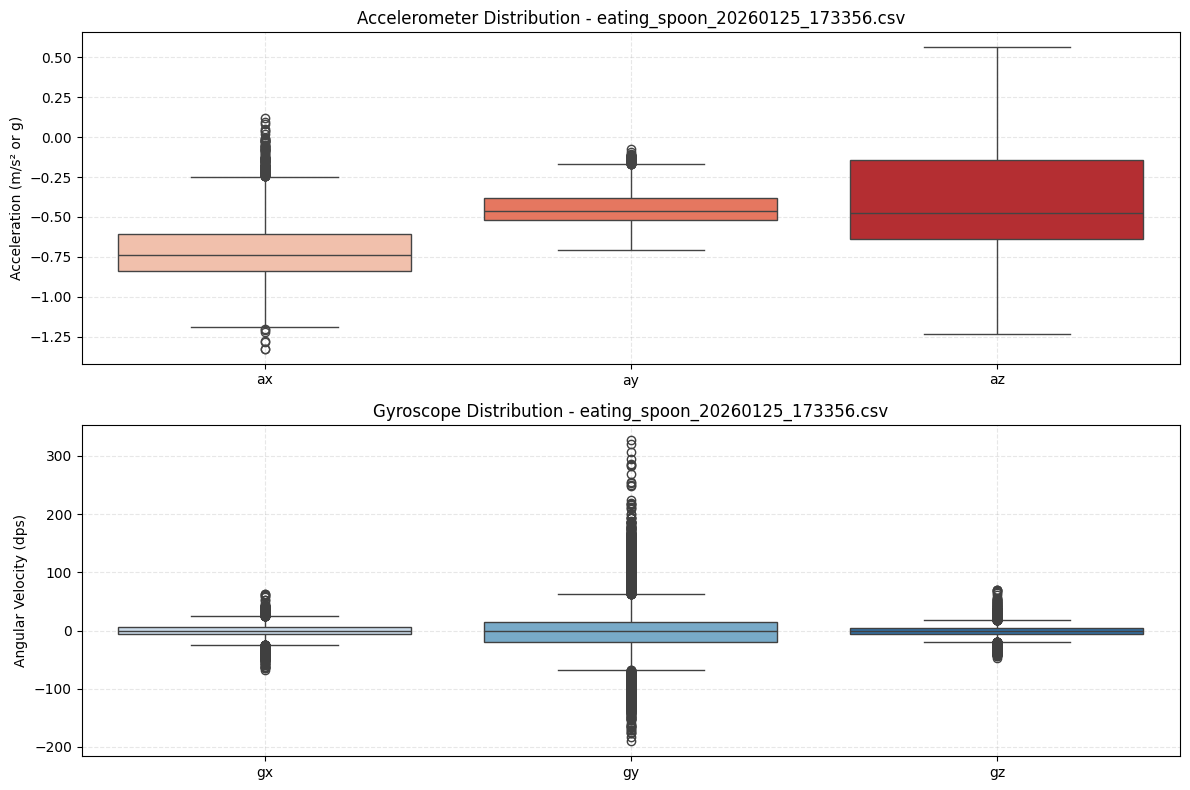

--------------------------------------------------
Generating Box Plot for: jogging_20260125_181023.csv


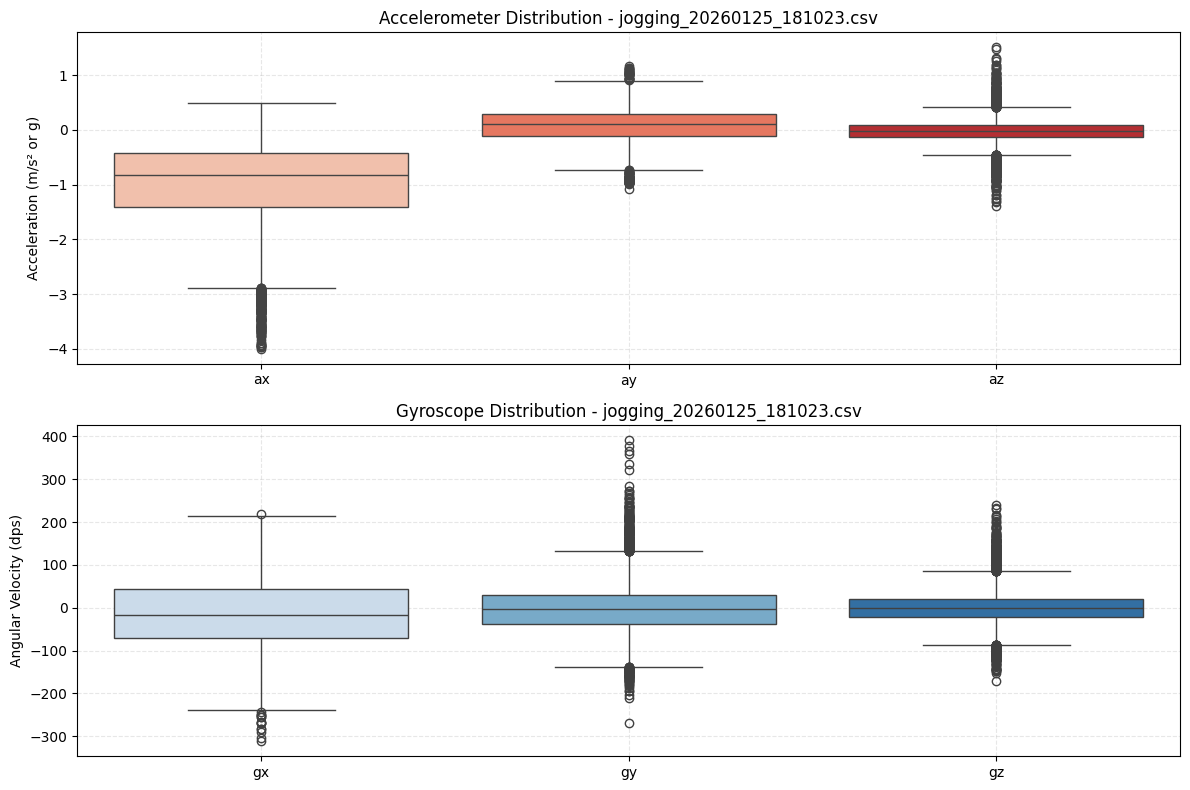

--------------------------------------------------
Generating Box Plot for: phone_interaction_1_20260201_005353.csv


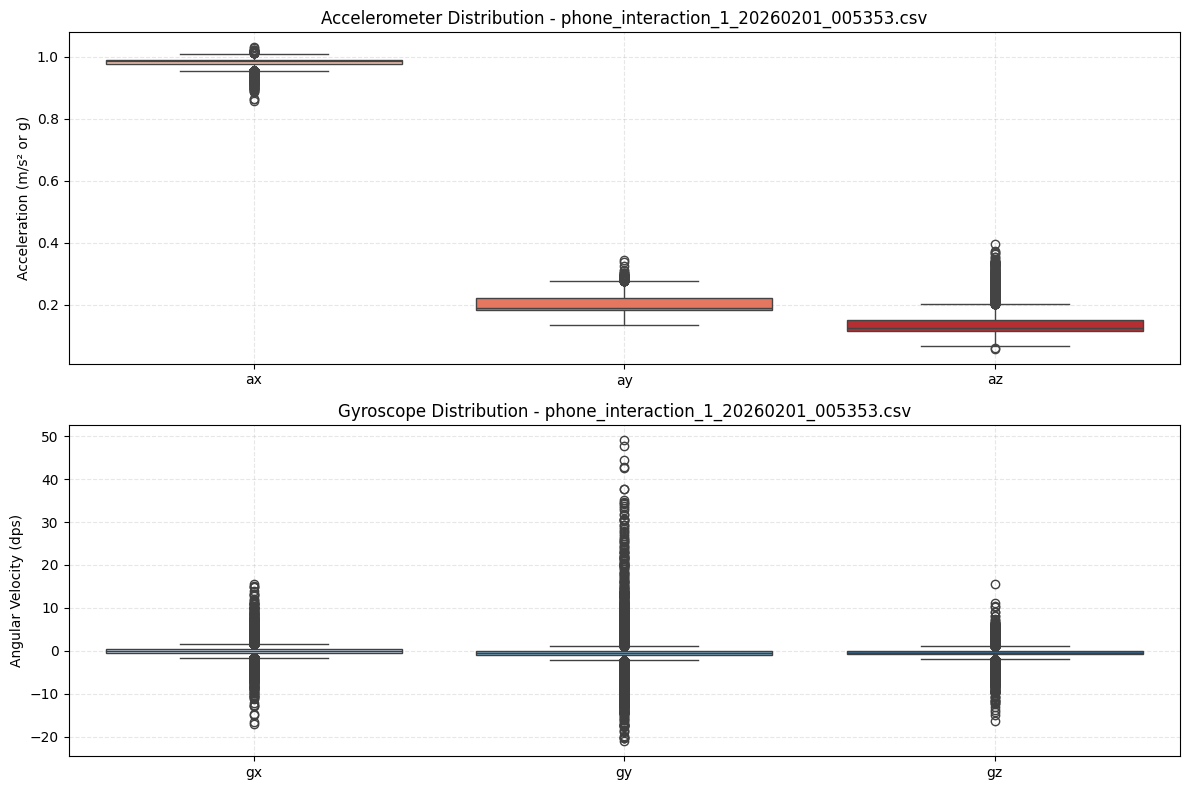

--------------------------------------------------
Generating Box Plot for: pick_place_1_20260131_114737.csv


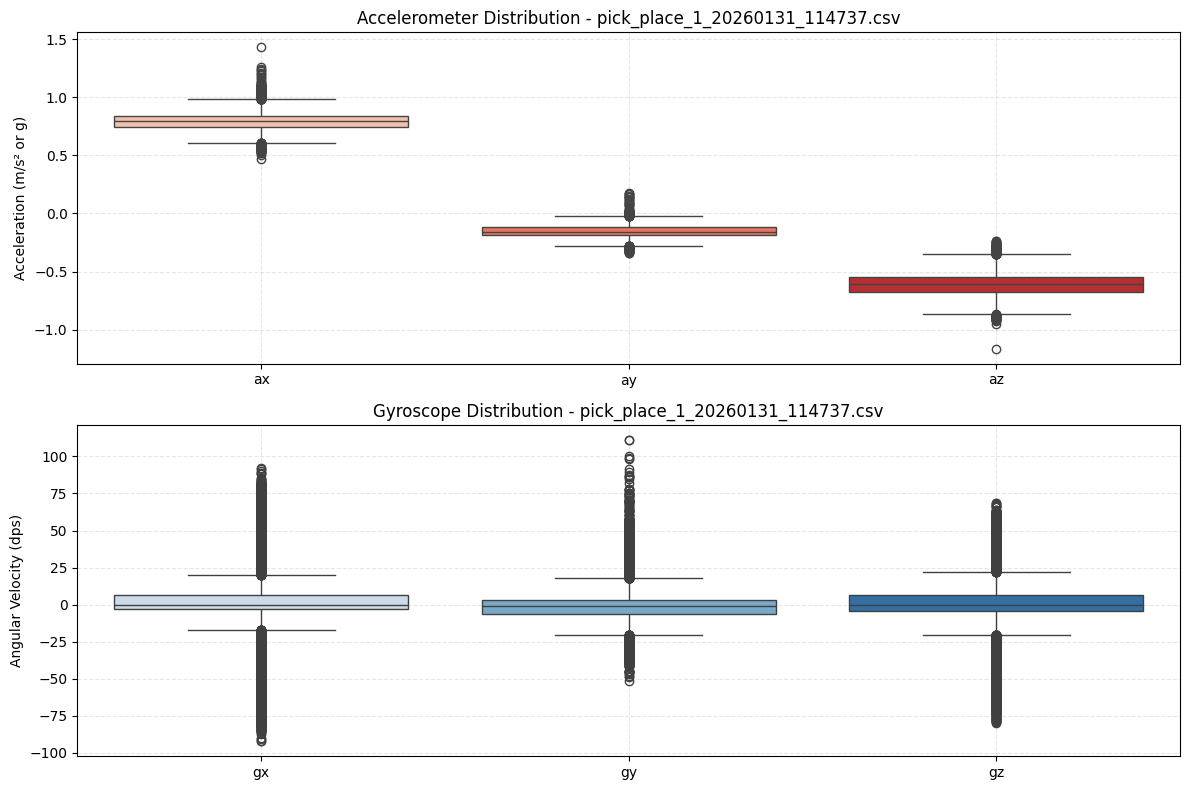

--------------------------------------------------
Generating Box Plot for: sitting_1_20260131_112629.csv


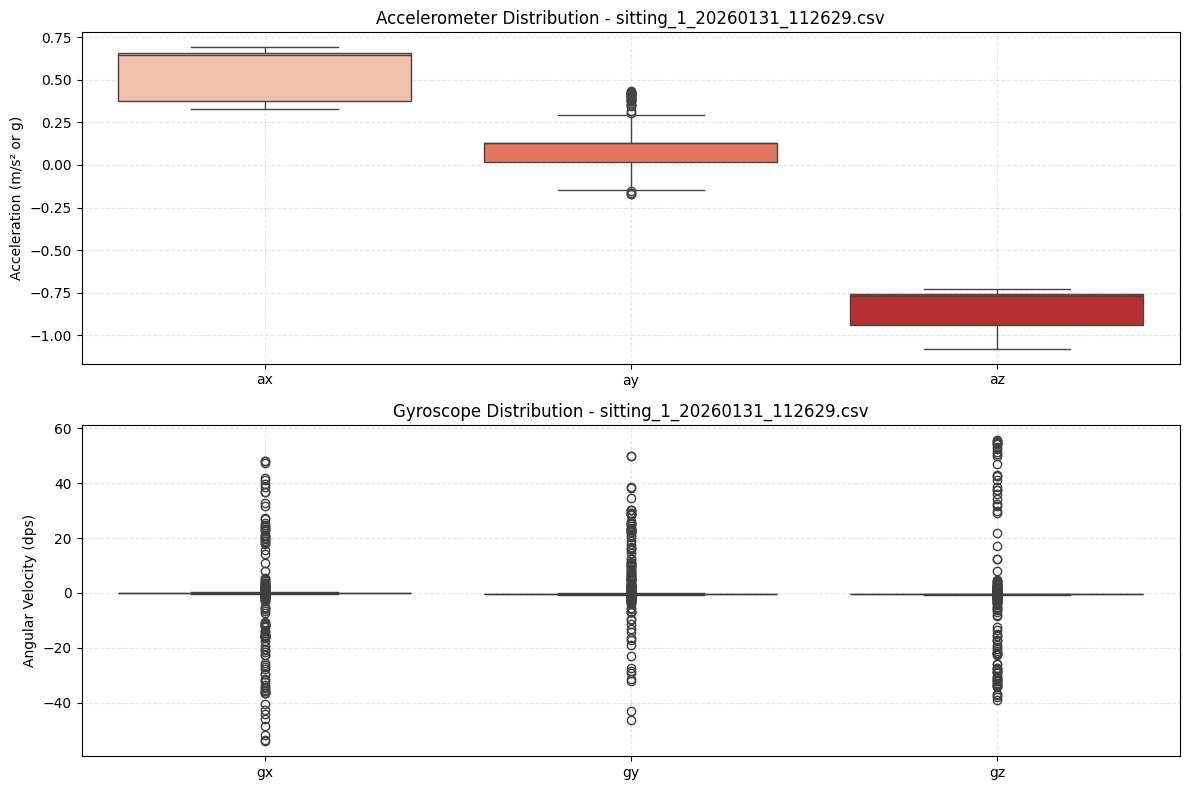

--------------------------------------------------
Generating Box Plot for: sit_stand_sit_20260125_182628.csv


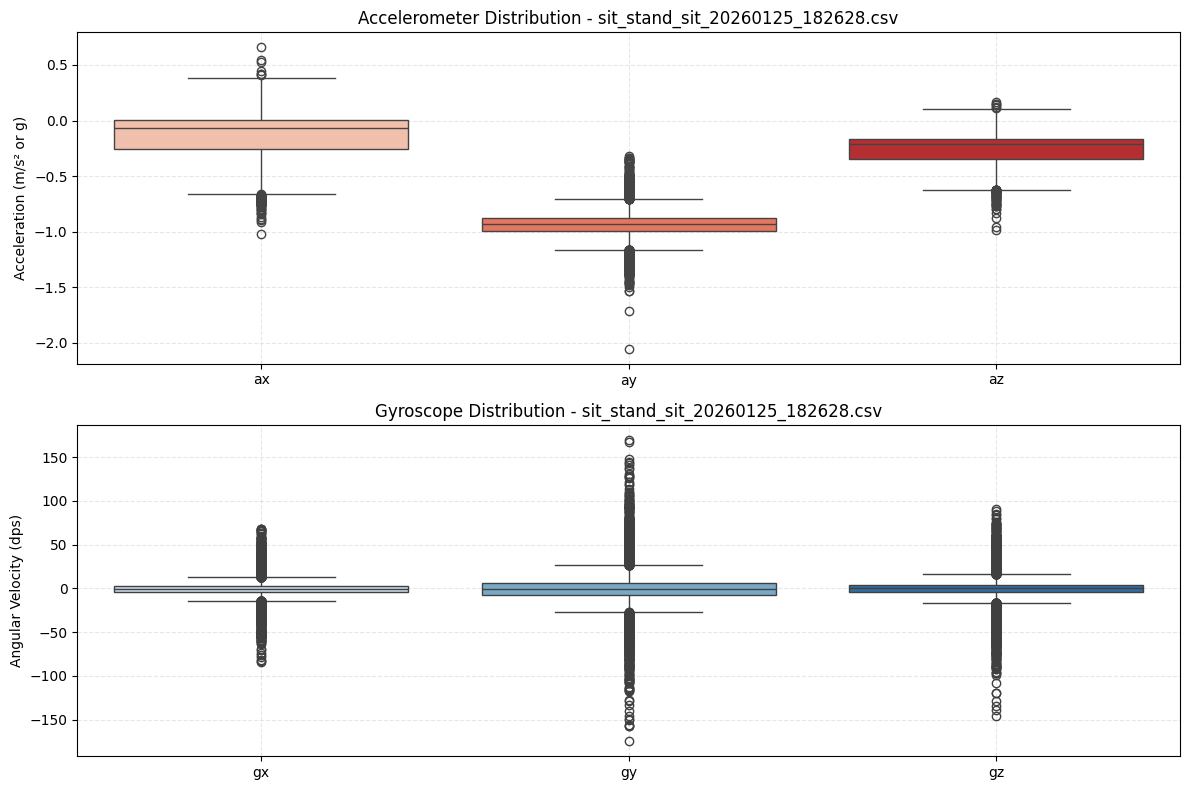

--------------------------------------------------
Generating Box Plot for: stair_down_20260125_181616.csv


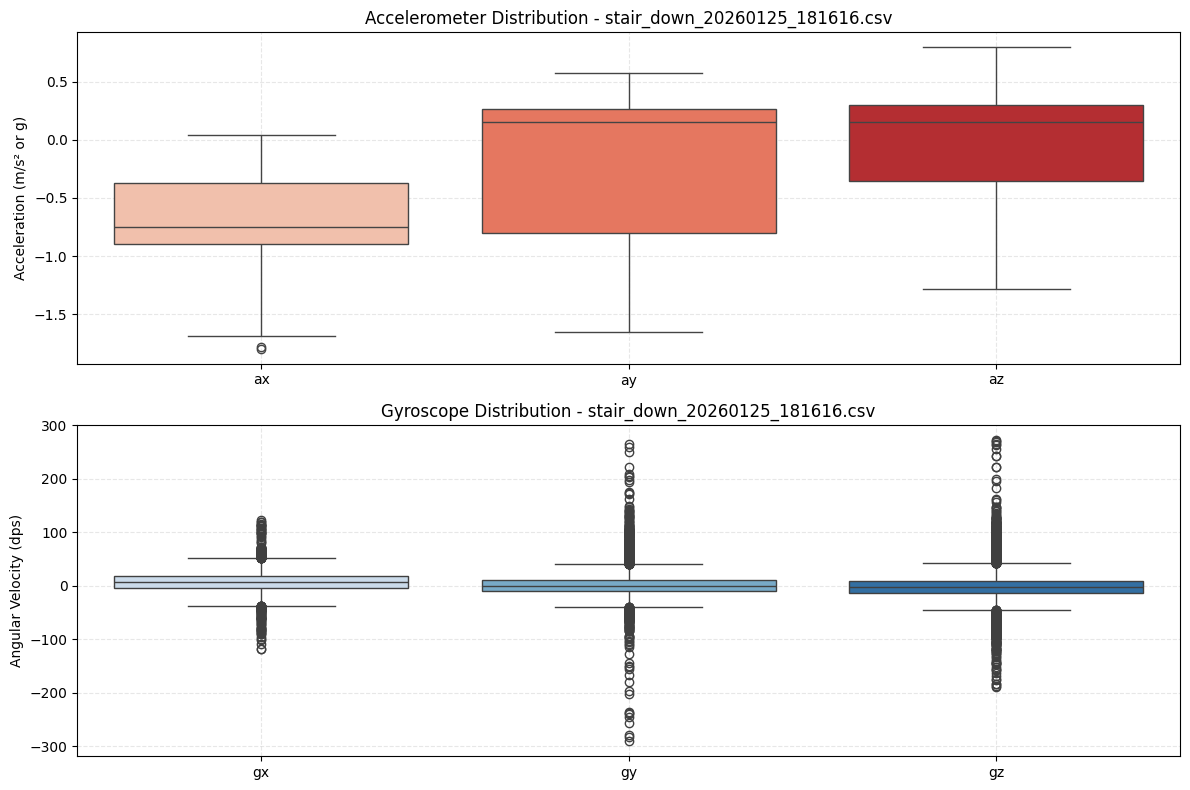

--------------------------------------------------
Generating Box Plot for: stair_up_20260125_182012.csv


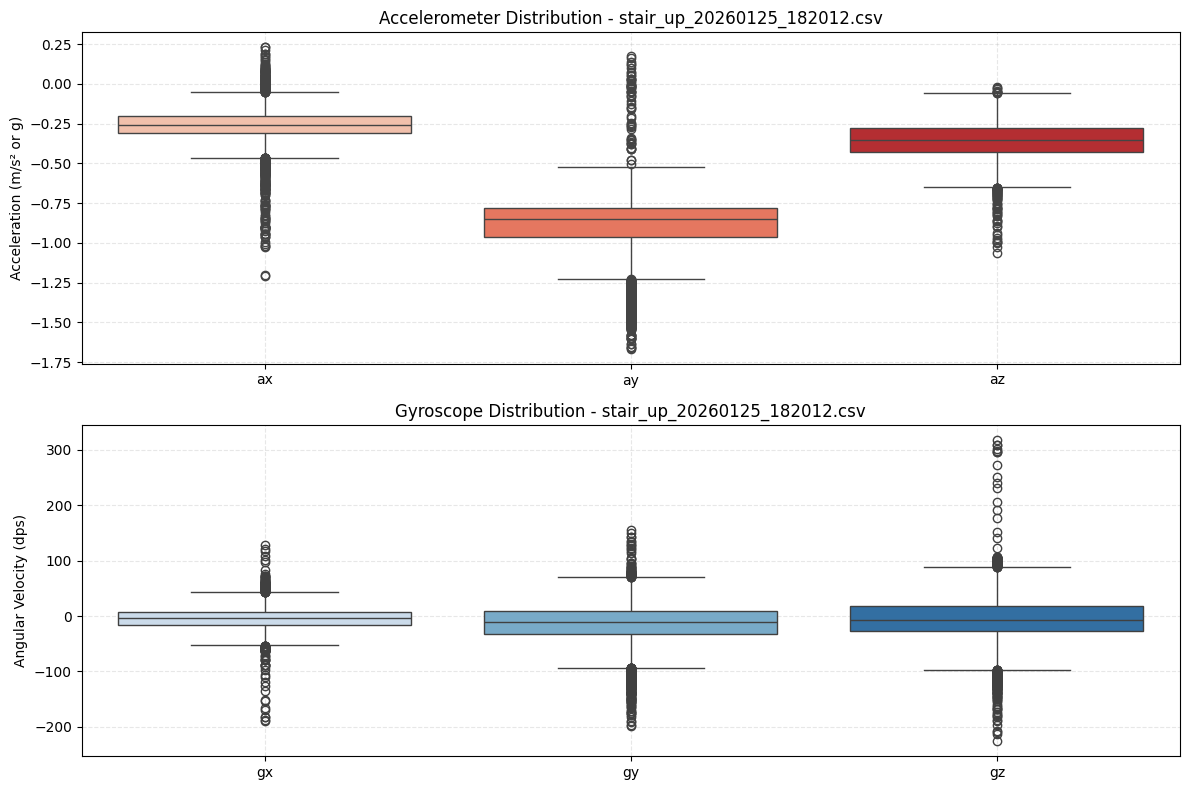

--------------------------------------------------
Generating Box Plot for: standing_1_20260201_001151.csv


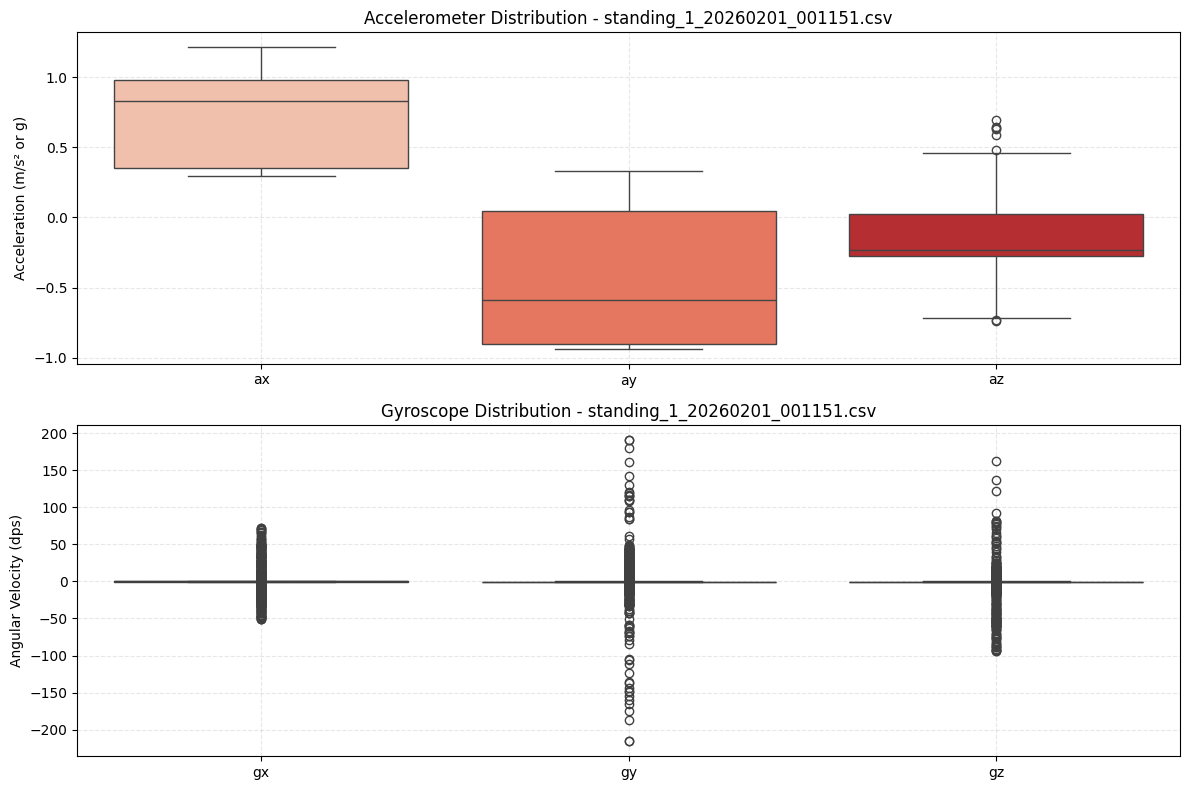

--------------------------------------------------
Generating Box Plot for: walking_abha_new_20260220_213943.csv


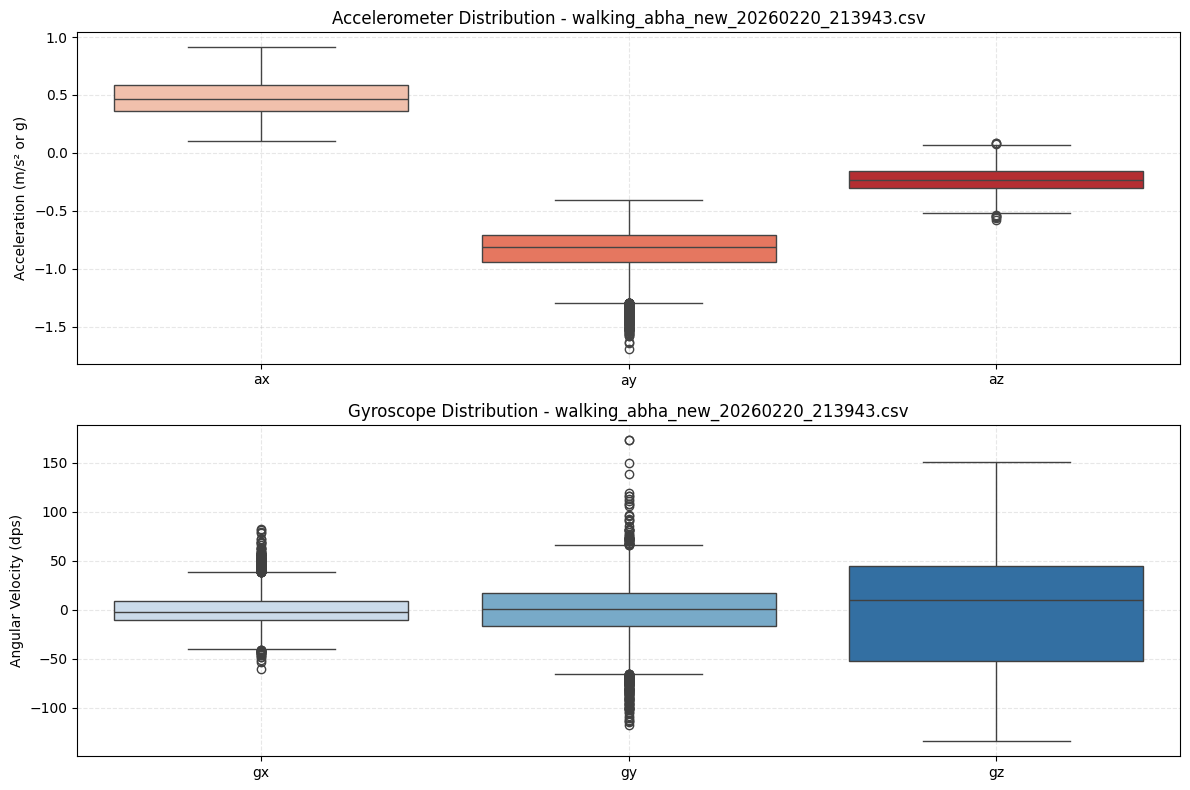

--------------------------------------------------


In [5]:
def plot_boxplots_all_files(directory):
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    
    print(f"Found {len(all_files)} files in {directory}...")
    
    for filepath in all_files:
        filename = os.path.basename(filepath)
        
        if "processed" in filename.lower():
            continue
            
        try:
            df = pd.read_csv(filepath)
            if df.empty: continue
            
            df.columns = df.columns.str.strip().str.lower()
            
            if 'ax' not in df.columns: continue
                
        except Exception as e:
            print(f"Error reading {filename}: {e}")
            continue

        print(f"Generating Box Plot for: {filename}")
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
        
        accel_data = df[['ax', 'ay', 'az']]
        sns.boxplot(data=accel_data, ax=ax1, palette="Reds")
        
        ax1.set_title(f'Accelerometer Distribution - {filename}')
        ax1.set_ylabel('Acceleration (m/s² or g)')
        ax1.grid(True, linestyle='--', alpha=0.3)

        if 'gx' in df.columns:
            gyro_data = df[['gx', 'gy', 'gz']]
            sns.boxplot(data=gyro_data, ax=ax2, palette="Blues")
            
            ax2.set_title(f'Gyroscope Distribution - {filename}')
            ax2.set_ylabel('Angular Velocity (dps)')
            ax2.grid(True, linestyle='--', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        print("-" * 50)

plot_boxplots_all_files(DATA_DIR)

Scanning 13 files...


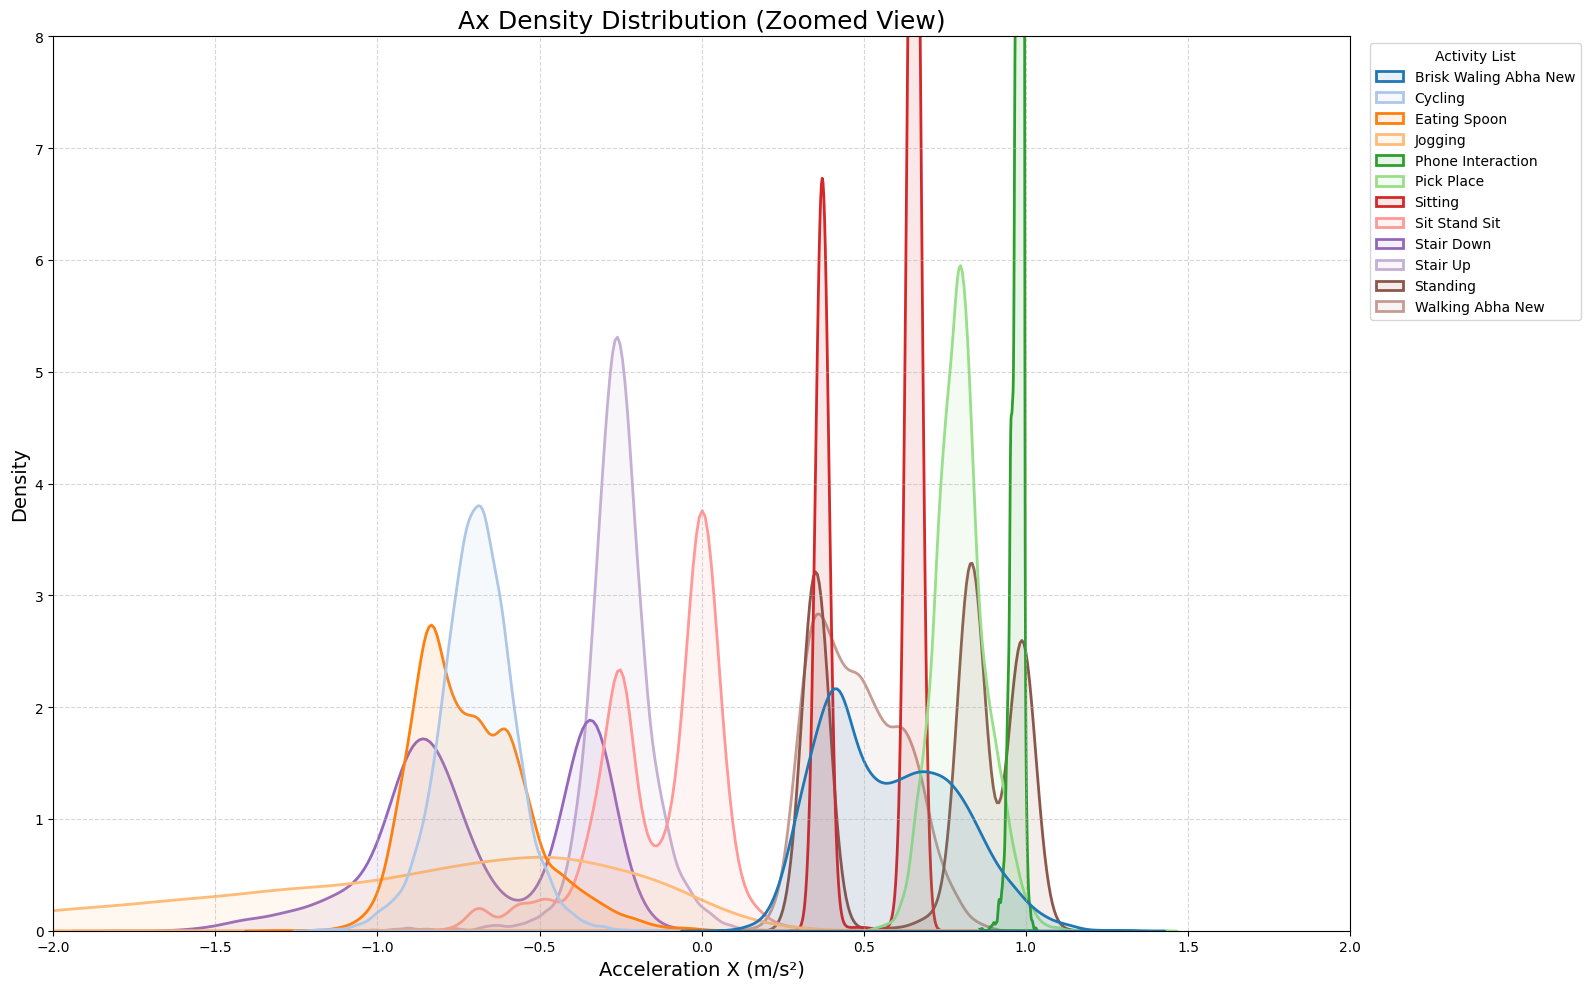

In [7]:
X_LIMIT = (-2, 2)  
Y_LIMIT = (0, 8)       

def plot_ax_density_optimized(directory):

    all_files = glob.glob(os.path.join(directory, "*.csv"))
    valid_data = []
    
    print(f"Scanning {len(all_files)} files...")

    for filepath in all_files:
        filename = os.path.basename(filepath)
        if "processed" in filename.lower(): continue

        try:
            df = pd.read_csv(filepath)
            df.columns = df.columns.str.strip().str.lower()
            
            if 'ax' in df.columns:
                base_name = os.path.splitext(filename)[0]
                parts = base_name.split('_')
                activity_parts = [p for p in parts if not any(char.isdigit() for char in p)]
                activity_label = " ".join(activity_parts).title()
                
                temp_df = pd.DataFrame({'Ax': df['ax'], 'Activity': activity_label})
                valid_data.append(temp_df)
                
        except Exception:
            continue

    if not valid_data: return
    combined_df = pd.concat(valid_data, ignore_index=True)
    
    plt.figure(figsize=(16, 10))
    
    ax_plot = sns.kdeplot(
        data=combined_df, 
        x='Ax', 
        hue='Activity', 
        fill=True, 
        common_norm=False, 
        alpha=0.1,         
        linewidth=2,
        palette="tab20"    
    )
    

    plt.xlim(X_LIMIT)      
    plt.ylim(Y_LIMIT)      
    
    plt.title(f'Ax Density Distribution (Zoomed View)', fontsize=18)
    plt.xlabel('Acceleration X (m/s²)', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    
 
    try:
        sns.move_legend(ax_plot, "upper left", bbox_to_anchor=(1.01, 1), title='Activity List')
    except:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_ax_density_optimized(DATA_DIR)

Scanning for Ay data: C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities
Processed Ay for: Brisk Waling Abha New
Processed Ay for: Cycling
Processed Ay for: Eating Spoon
Processed Ay for: Jogging
Processed Ay for: Phone Interaction
Processed Ay for: Pick Place
Processed Ay for: Sitting
Processed Ay for: Sit Stand Sit
Processed Ay for: Stair Down
Processed Ay for: Stair Up
Processed Ay for: Standing
Processed Ay for: Walking Abha New
----------------------------------------
Plotting Ay distribution for 12 activities...


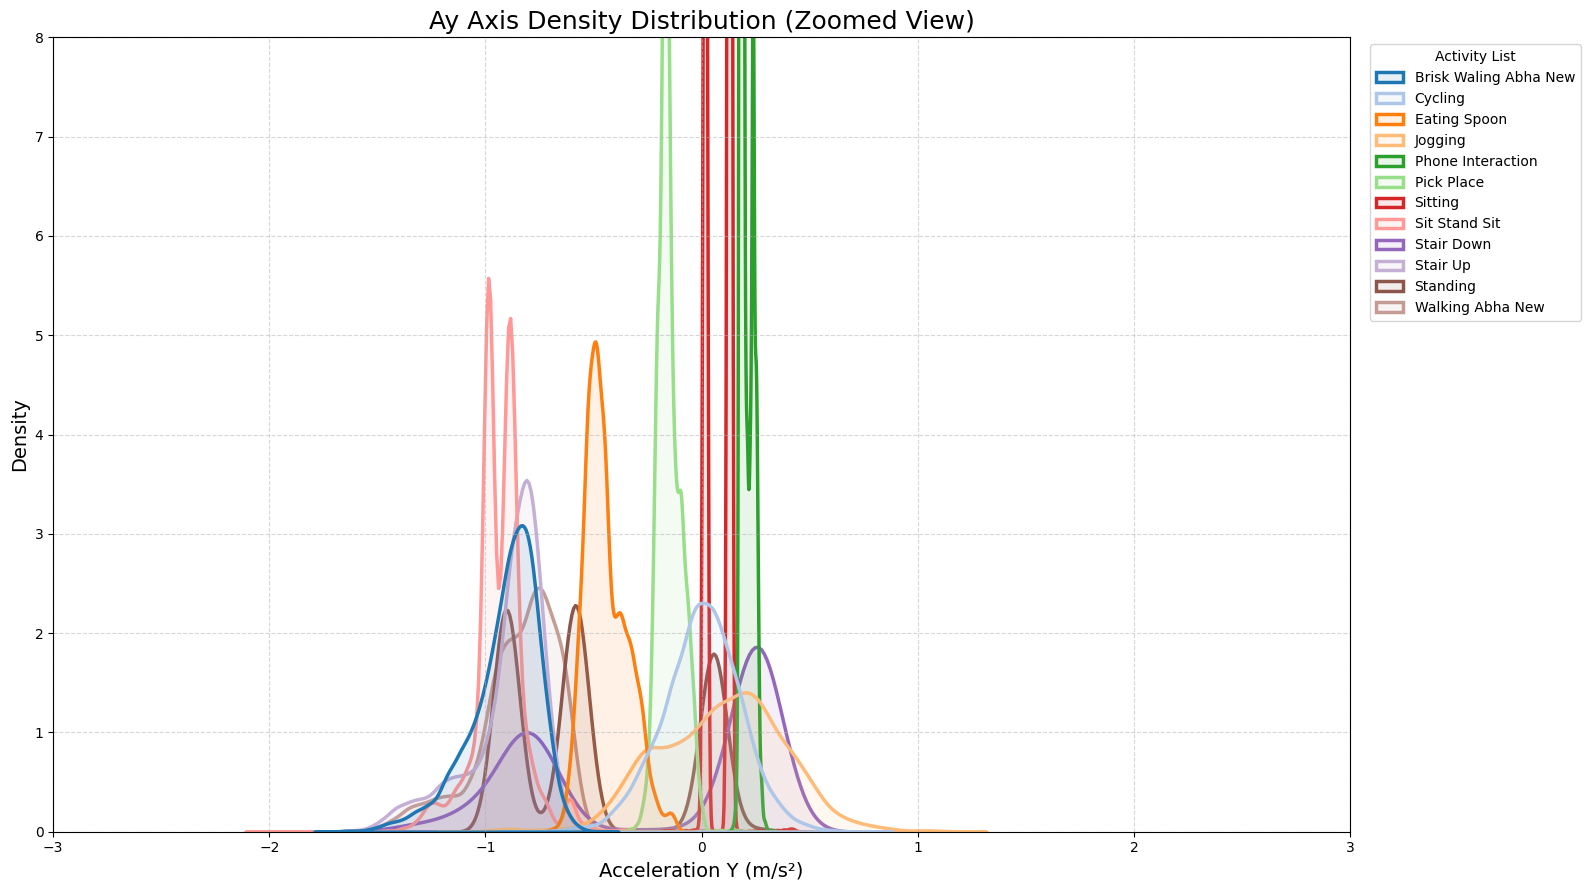

In [8]:
Y_AXIS_LIMIT = (0, 8)   
X_AXIS_LIMIT = (-3, 3)  

def plot_ay_density_optimized(directory):
    
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    valid_data = []
    
    print(f"Scanning for Ay data: {directory}")

    for filepath in all_files:
        filename = os.path.basename(filepath)
        if "processed" in filename.lower(): continue

        try:
            df = pd.read_csv(filepath)
            
            df.columns = df.columns.str.strip().str.lower()
            
            
            if 'ay' in df.columns:
                
                base_name = os.path.splitext(filename)[0]
                parts = base_name.split('_')
                activity_parts = [p for p in parts if not any(char.isdigit() for char in p)]
                activity_label = " ".join(activity_parts).title()
                
                
                temp_df = pd.DataFrame({
                    'Ay': df['ay'], 
                    'Activity': activity_label
                })
                valid_data.append(temp_df)
                print(f"Processed Ay for: {activity_label}")
                
        except Exception as e:
            print(f"Error: {e}")
            continue

    if not valid_data:
        print("No valid Ay data found.")
        return

    combined_df = pd.concat(valid_data, ignore_index=True)
    unique_acts = combined_df['Activity'].nunique()
    print("-" * 40)
    print(f"Plotting Ay distribution for {unique_acts} activities...")


    plt.figure(figsize=(16, 9))
    
    ax_plot = sns.kdeplot(
        data=combined_df, 
        x='Ay',                
        hue='Activity', 
        fill=True, 
        common_norm=False, 
        alpha=0.1,             
        linewidth=2.5,
        palette="tab20"        
    )
    
    plt.xlim(X_AXIS_LIMIT)
    plt.ylim(Y_AXIS_LIMIT)
    
    plt.title(f'Ay Axis Density Distribution (Zoomed View)', fontsize=18)
    plt.xlabel('Acceleration Y (m/s²)', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    try:
        sns.move_legend(ax_plot, "upper left", bbox_to_anchor=(1.01, 1), title='Activity List')
    except:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_ay_density_optimized(DATA_DIR)

Scanning for Az data: C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities
Processed Az for: Brisk Waling Abha New
Processed Az for: Cycling
Processed Az for: Eating Spoon
Processed Az for: Jogging
Processed Az for: Phone Interaction
Processed Az for: Pick Place
Processed Az for: Sitting
Processed Az for: Sit Stand Sit
Processed Az for: Stair Down
Processed Az for: Stair Up
Processed Az for: Standing
Processed Az for: Walking Abha New
----------------------------------------
Plotting Az distribution for 12 activities...


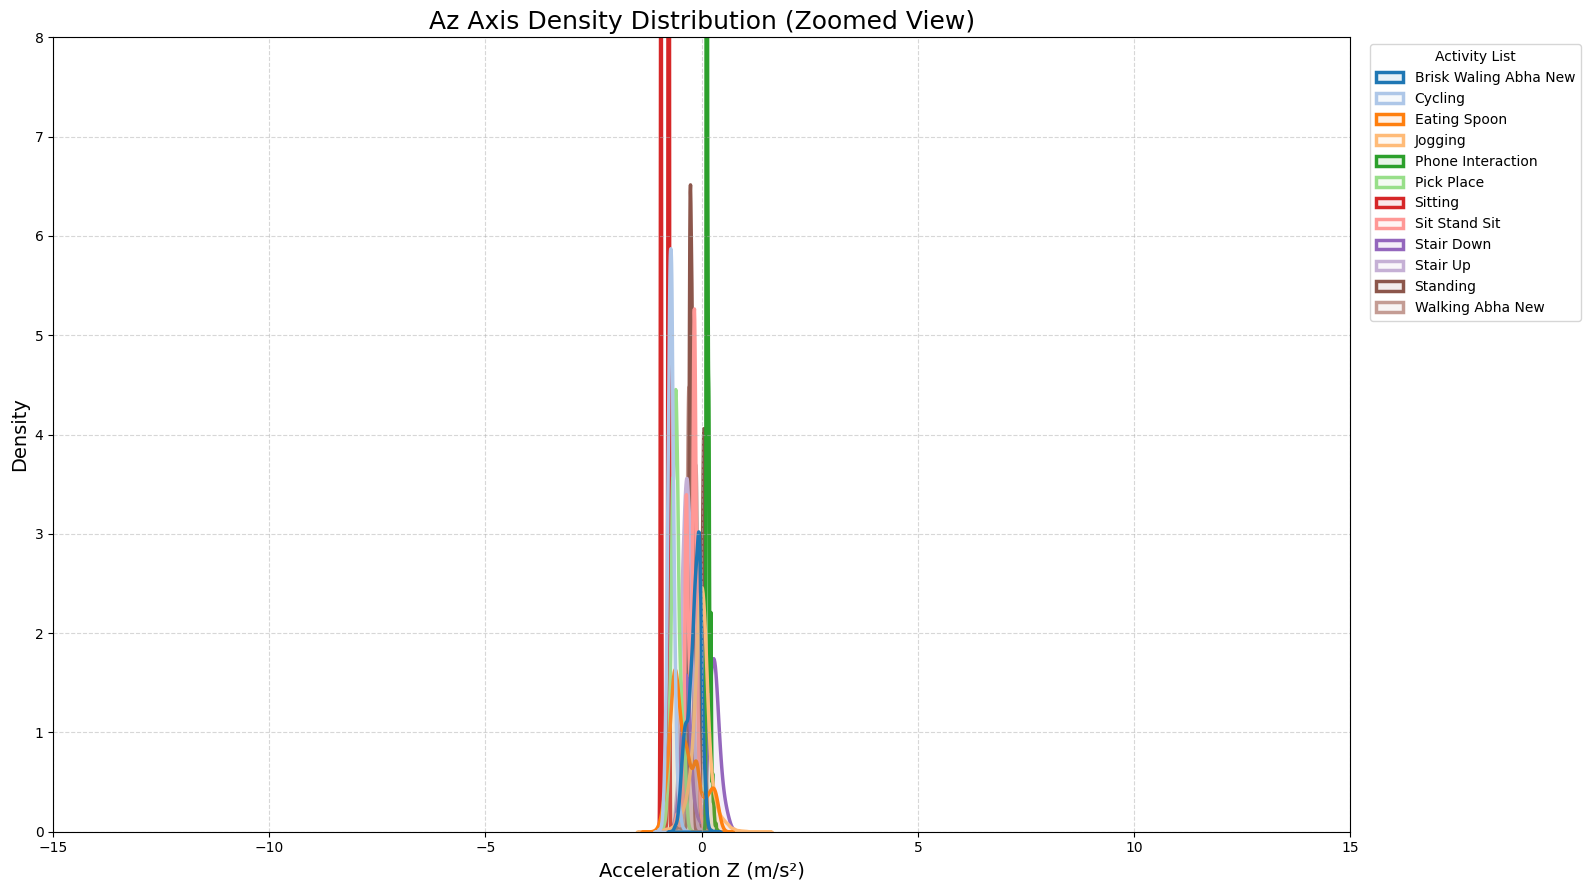

In [9]:
Y_AXIS_LIMIT = (0, 8)    
X_AXIS_LIMIT = (-15, 15) 

def plot_az_density_optimized(directory):
    
    all_files = glob.glob(os.path.join(directory, "*.csv"))
    valid_data = []
    
    print(f"Scanning for Az data: {directory}")

    for filepath in all_files:
        filename = os.path.basename(filepath)
        if "processed" in filename.lower(): continue

        try:
            df = pd.read_csv(filepath)
            df.columns = df.columns.str.strip().str.lower()
            
            
            if 'az' in df.columns:
               
                base_name = os.path.splitext(filename)[0]
                parts = base_name.split('_')
                activity_parts = [p for p in parts if not any(char.isdigit() for char in p)]
                activity_label = " ".join(activity_parts).title()
                
               
                temp_df = pd.DataFrame({
                    'Az': df['az'], 
                    'Activity': activity_label
                })
                valid_data.append(temp_df)
                print(f"Processed Az for: {activity_label}")
                
        except Exception as e:
            print(f"Error: {e}")
            continue

    if not valid_data:
        print("No valid Az data found.")
        return

    combined_df = pd.concat(valid_data, ignore_index=True)
    unique_acts = combined_df['Activity'].nunique()
    print("-" * 40)
    print(f"Plotting Az distribution for {unique_acts} activities...")

    
    plt.figure(figsize=(16, 9))
    
    ax_plot = sns.kdeplot(
        data=combined_df, 
        x='Az',                
        hue='Activity', 
        fill=True, 
        common_norm=False, 
        alpha=0.1,             
        linewidth=2.5,
        palette="tab20"        
    )
    
   
    plt.xlim(X_AXIS_LIMIT)
    plt.ylim(Y_AXIS_LIMIT)
    
    plt.title(f'Az Axis Density Distribution (Zoomed View)', fontsize=18)
    plt.xlabel('Acceleration Z (m/s²)', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    
   
    try:
        sns.move_legend(ax_plot, "upper left", bbox_to_anchor=(1.01, 1), title='Activity List')
    except:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_az_density_optimized(DATA_DIR)

Processing Gx...


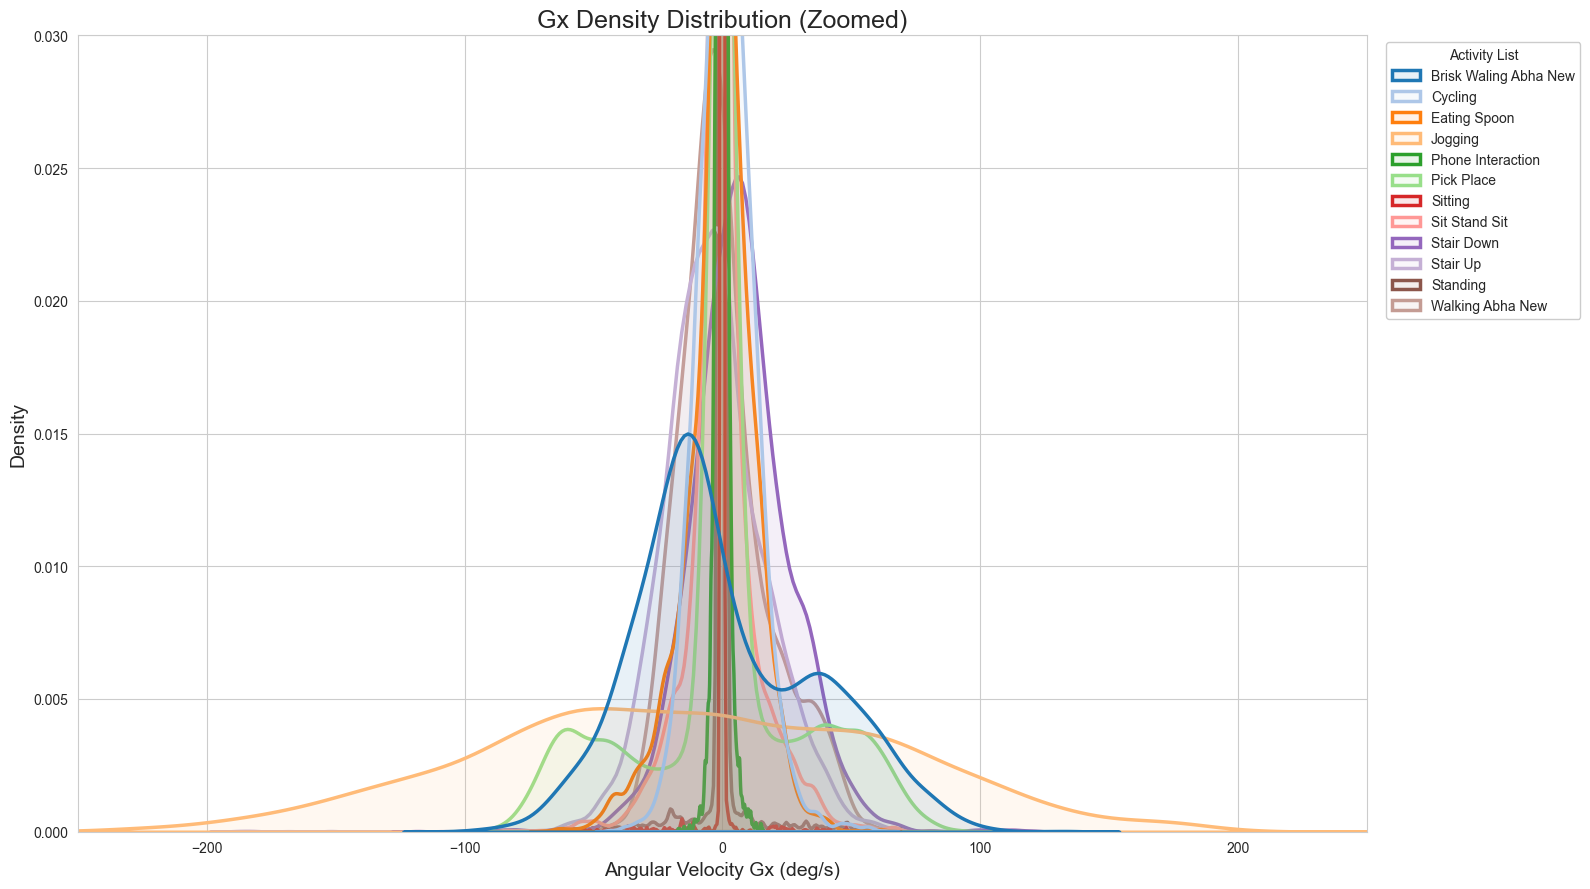

--------------------------------------------------
Processing Gy...


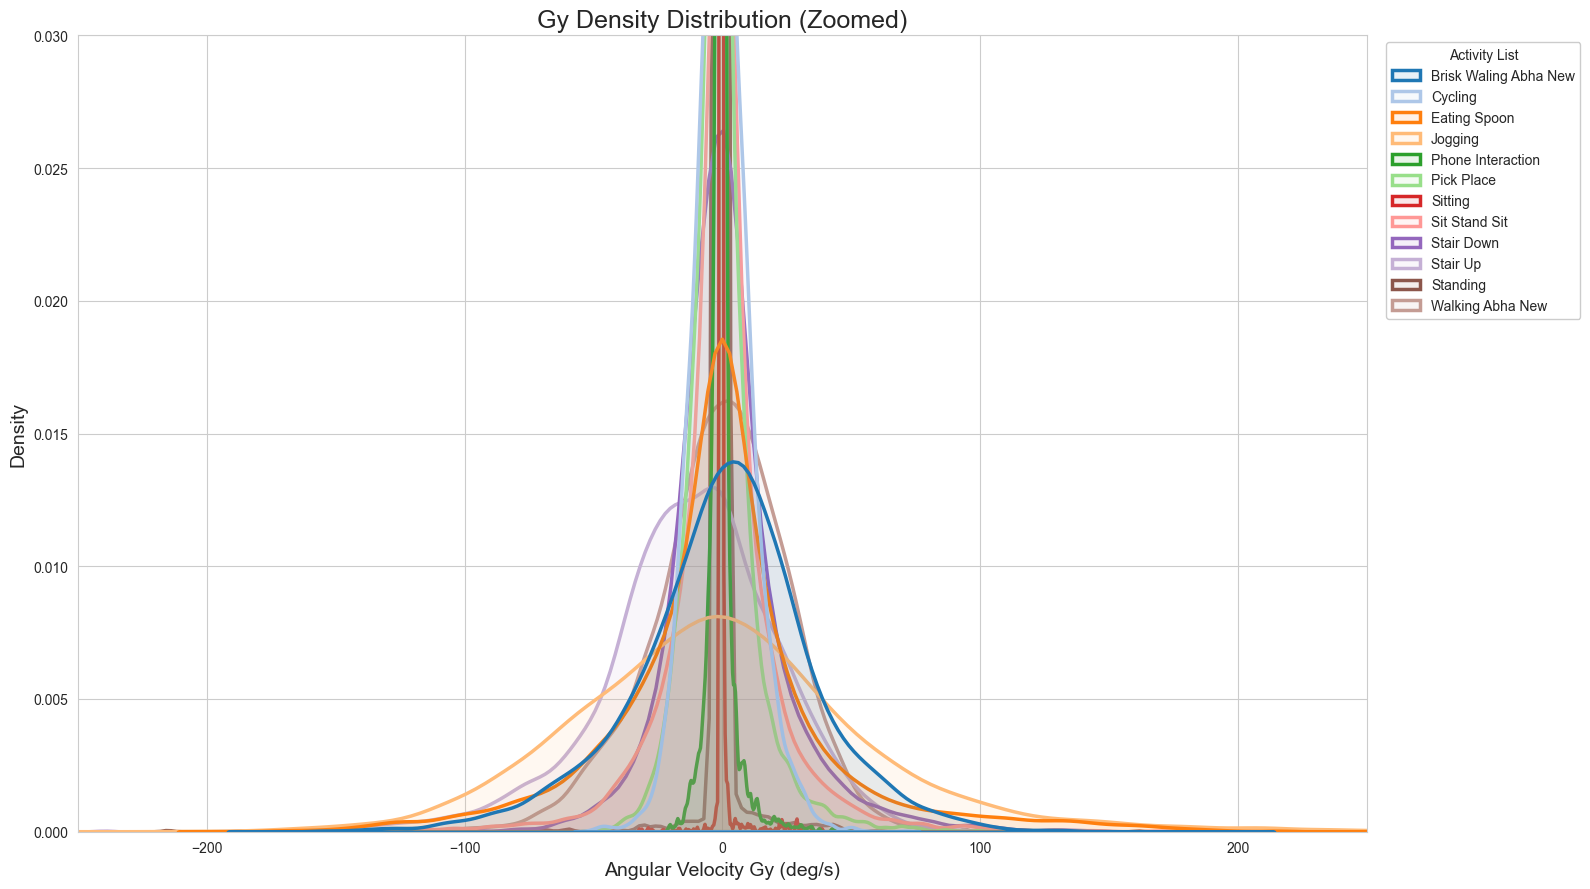

--------------------------------------------------
Processing Gz...


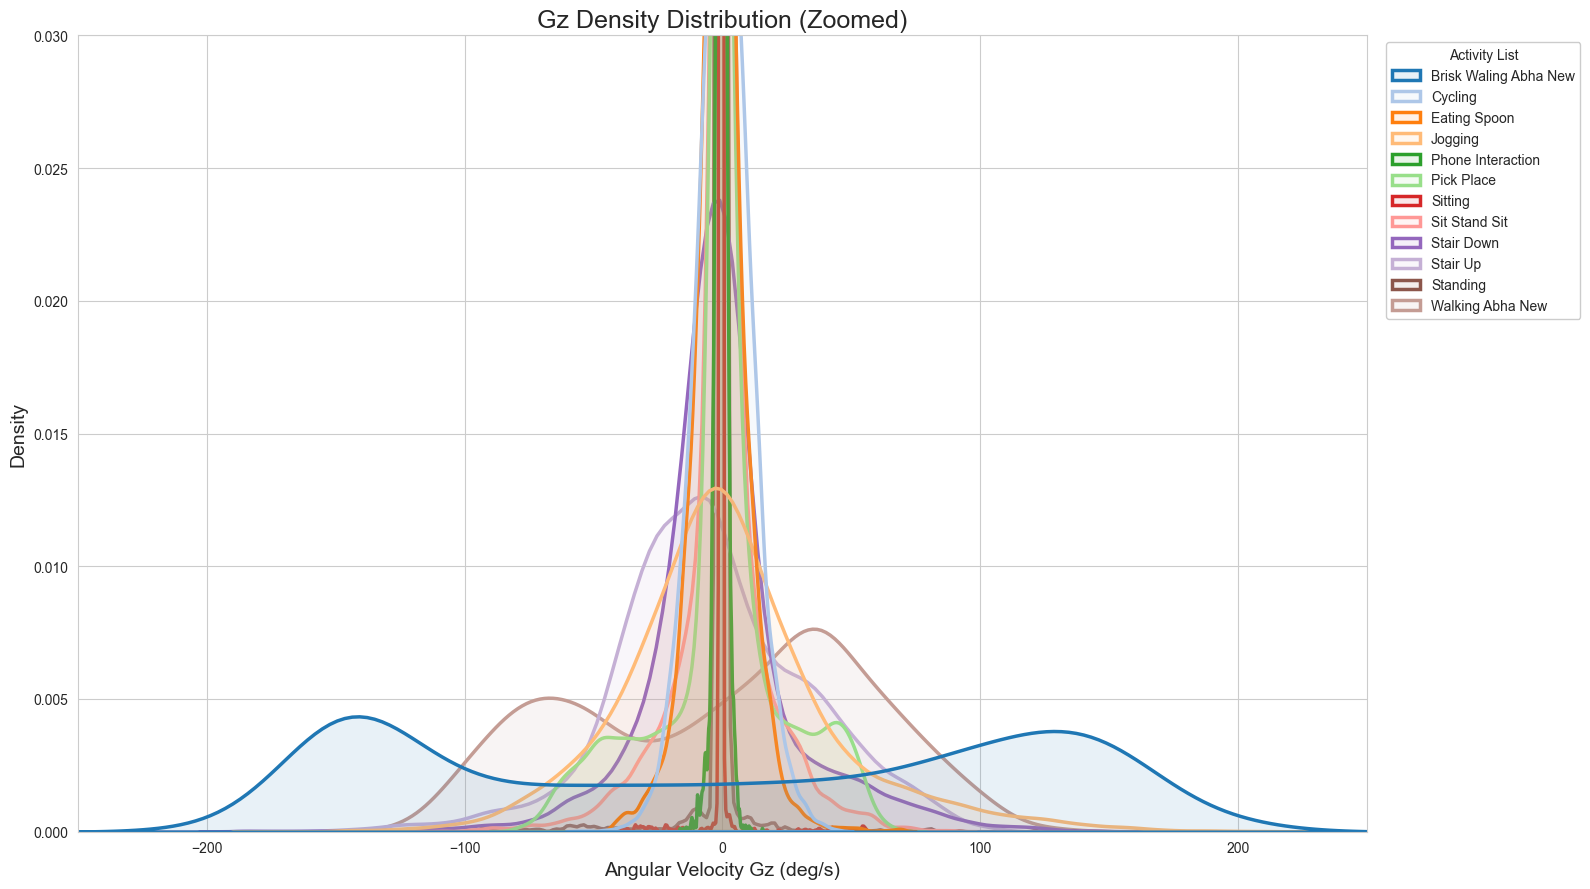

--------------------------------------------------


In [10]:
X_LIMIT = (-250, 250) 
Y_LIMIT = (0, 0.03)   

def plot_gyro_densities_final(directory):

    sns.set_style("whitegrid")
    

    for axis in ['gx', 'gy', 'gz']:
        all_files = glob.glob(os.path.join(directory, "*.csv"))
        valid_data = []
        axis_title = axis.capitalize() # "Gx", "Gy", "Gz"
        
        print(f"Processing {axis_title}...")

        for filepath in all_files:
            filename = os.path.basename(filepath)
            if "processed" in filename.lower(): continue

            try:
                df = pd.read_csv(filepath)
                df.columns = df.columns.str.strip().str.lower()
                
                if axis in df.columns:
                    # Clean Label
                    base_name = os.path.splitext(filename)[0]
                    parts = base_name.split('_')
                    activity_parts = [p for p in parts if not any(char.isdigit() for char in p)]
                    activity_label = " ".join(activity_parts).title()
                    
                    temp_df = pd.DataFrame({
                        'Value': df[axis], 
                        'Activity': activity_label
                    })
                    valid_data.append(temp_df)
                    
            except Exception:
                continue

        if not valid_data:
            print(f"Skipping {axis} (No data found)")
            continue

        combined_df = pd.concat(valid_data, ignore_index=True)
        unique_acts = combined_df['Activity'].nunique()


        plt.figure(figsize=(16, 9))
        
        ax_plot = sns.kdeplot(
            data=combined_df, 
            x='Value', 
            hue='Activity', 
            fill=True, 
            common_norm=False, 
            alpha=0.1,             
            linewidth=2.5,
            palette="tab20"        
        )
        

        plt.xlim(X_LIMIT)
        plt.ylim(Y_LIMIT)  
        
        plt.title(f'{axis_title} Density Distribution (Zoomed)', fontsize=18)
        plt.xlabel(f'Angular Velocity {axis_title} (deg/s)', fontsize=14)
        plt.ylabel('Density', fontsize=14)
        

        try:
            sns.move_legend(ax_plot, "upper left", bbox_to_anchor=(1.01, 1), title='Activity List')
            leg = ax_plot.get_legend()
            leg.get_frame().set_facecolor('white')
            leg.get_frame().set_alpha(1.0)
        except:
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', facecolor='white', framealpha=1)

        plt.tight_layout()
        plt.show()
        print("-" * 50)


plot_gyro_densities_final(DATA_DIR)

### Data Cluster Analysis using t-SNE

- **Dimensionality Reduction:** Our data is 6-dimensional *(Aₓ, Aᵧ, A_z, Gₓ, Gᵧ, G_z)*. We cannot easily visualize 6 dimensions at once.

- **Cluster Discovery:** t-SNE squashes these 6 dimensions into a 2D map. It is smart enough to group similar data points together.

- **Separability Check:**
  - If distinct “islands” of color appear (for example, all **"Sitting"** points are far from **"Walking"**), the model will likely be highly accurate.
  - If the colors are mashed together like mixed paint, the model will struggle to distinguish them.


Scanning 13 files...
Loaded: Brisk Waling Abha New (198 points)
Loaded: Cycling (188 points)
Loaded: Eating Spoon (200 points)
Loaded: Jogging (198 points)
Loaded: Phone Interaction (300 points)
Loaded: Pick Place (300 points)
Loaded: Sitting (300 points)
Loaded: Sit Stand Sit (200 points)
Loaded: Stair Down (197 points)
Loaded: Stair Up (194 points)
Loaded: Standing (201 points)
Loaded: Walking Abha New (198 points)
----------------------------------------
Running t-SNE on 2674 total points...
This may take a moment...


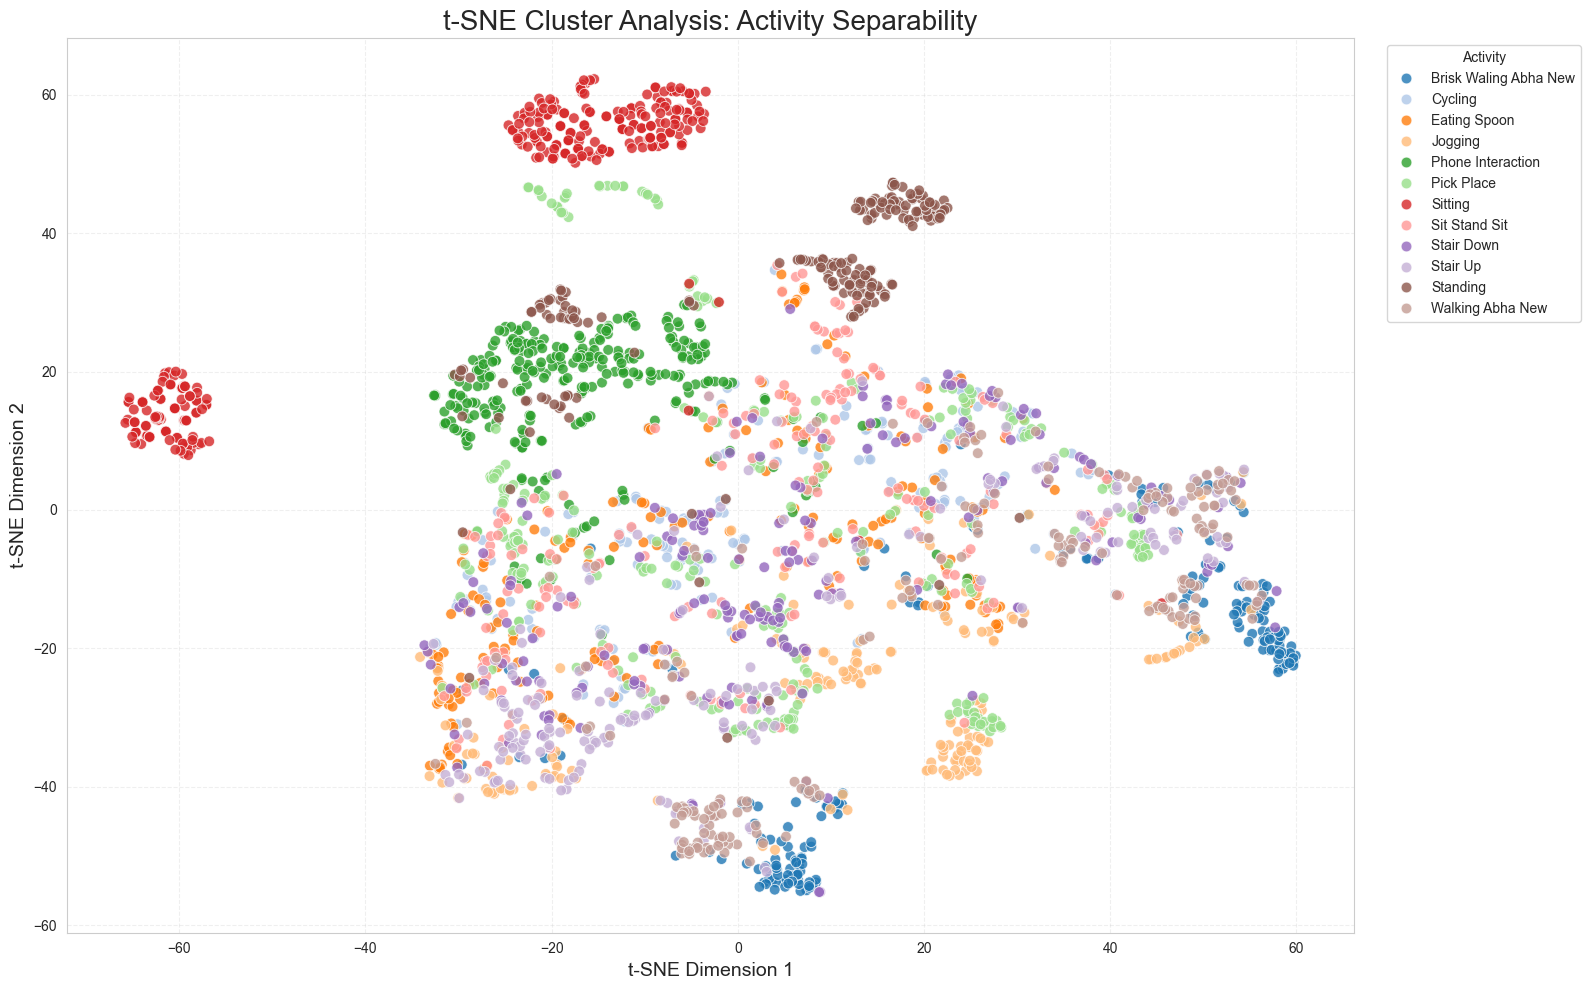

In [11]:
SAMPLE_RATE = 50 

def plot_tsne_clusters(directory):

    all_files = glob.glob(os.path.join(directory, "*.csv"))
    valid_data = []
    
    print(f"Scanning {len(all_files)} files...")

    for filepath in all_files:
        filename = os.path.basename(filepath)
        if "processed" in filename.lower(): continue

        try:
            df = pd.read_csv(filepath)

            df.columns = df.columns.str.strip().str.lower()
            
            if {'ax', 'ay', 'az', 'gx', 'gy', 'gz'}.issubset(df.columns):
                # Clean Label
                base_name = os.path.splitext(filename)[0]
                parts = base_name.split('_')
                activity_parts = [p for p in parts if not any(char.isdigit() for char in p)]
                activity_label = " ".join(activity_parts).title()
                
                temp_df = df[['ax', 'ay', 'az', 'gx', 'gy', 'gz']].iloc[::SAMPLE_RATE].copy()
                temp_df['Activity'] = activity_label
                valid_data.append(temp_df)
                print(f"Loaded: {activity_label} ({len(temp_df)} points)")
                
        except Exception as e:
            print(f"Skipping {filename}: {e}")
            continue

    if not valid_data:
        print("No valid data found.")
        return

    combined_df = pd.concat(valid_data, ignore_index=True)
    print("-" * 40)
    print(f"Running t-SNE on {len(combined_df)} total points...")
    print("This may take a moment...")

    X = combined_df.drop(columns=['Activity'])
    y = combined_df['Activity']
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    X_embedded = tsne.fit_transform(X)

    tsne_df = pd.DataFrame(X_embedded, columns=['Component 1', 'Component 2'])
    tsne_df['Activity'] = y.values

    plt.figure(figsize=(16, 10))
    sns.scatterplot(
        data=tsne_df,
        x='Component 1',
        y='Component 2',
        hue='Activity',
        palette="tab20", 
        s=60,            
        alpha=0.8        
    )
    
    plt.title('t-SNE Cluster Analysis: Activity Separability', fontsize=20)
    plt.xlabel('t-SNE Dimension 1', fontsize=14)
    plt.ylabel('t-SNE Dimension 2', fontsize=14)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Activity', frameon=True)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_tsne_clusters(DATA_DIR)

---
### **Task 2: Feature Engineering and Model Development (5 Marks)**

### Window-Based Feature Extraction

- Segment the raw IMU data using a **sliding window** of size  
  **N = 20 samples**
- Use a **50% overlap** between consecutive windows

---

In [12]:
WINDOW_SIZE = 20        # N = 20 samples
OVERLAP_PERC = 0.50     # 50% overlap
STRIDE = int(WINDOW_SIZE * (1 - OVERLAP_PERC)) # 10 samples

#### For each window:

- The window consists of **20 rows × 6 IMU channels**  
  *(Ax, Ay, Az, Gx, Gy, Gz)*

- Extract **at least 10 time-series features per channel**, such as:
  - Mean  
  - Minimum  
  - Maximum  
  - Standard deviation  
  - Other time-domain features

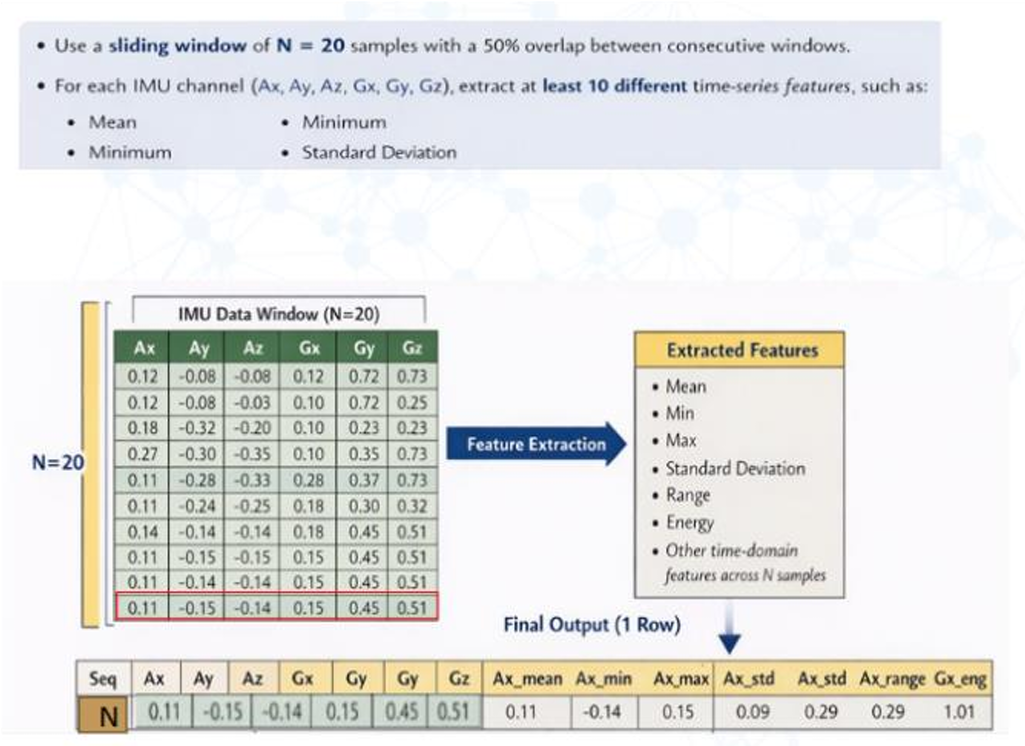

#### Final Output per Window

Each window must produce **one row**, consisting of:

- **Raw IMU values from the 20th (last) sample** of the window:  
  *(Ax[20], Ay[20], Az[20], Gx[20], Gy[20], Gz[20])*

- **All engineered features** computed over the full 20-sample window

---

In [13]:
def calculate_features(window_data):
    """
    Computes 11 robust time-domain features for a single channel window.
    """
    # 1. Mean
    mean_val = np.mean(window_data)
    # 2. Standard Deviation
    std_val = np.std(window_data)
    # 3. Minimum
    min_val = np.min(window_data)
    # 4. Maximum
    max_val = np.max(window_data)
    # 5. Variance (Captures spread better than Range)
    var_val = np.var(window_data)
    # 6. Root Mean Square (RMS)
    rms_val = np.sqrt(np.mean(window_data**2))
    # 7. Energy
    energy_val = np.sum(window_data**2)
    # 8. Interquartile Range (IQR)
    iqr_val = np.percentile(window_data, 75) - np.percentile(window_data, 25)
    # 9. Median (Robust central tendency)
    median_val = np.median(window_data)
    
    #Skewness & Kurtosis
    if std_val < 1e-6:
        skew_val = 0.0
        kurt_val = 0.0
    else:
        # 10. Skewness
        skew_val = stats.skew(window_data, nan_policy='omit')
        # 11. Kurtosis
        kurt_val = stats.kurtosis(window_data, nan_policy='omit')

    return [mean_val, std_val, min_val, max_val, var_val, rms_val, 
            energy_val, iqr_val, median_val, skew_val, kurt_val]

def process_file_sliding_window(filepath):
    try:
        df = pd.read_csv(filepath)
        
        df.columns = [c.strip() for c in df.columns]
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None

    # Storage for processed rows
    processed_data = []
    
    feature_suffixes = ['_mean', '_std', '_min', '_max', '_var', '_rms', 
                        '_eng', '_iqr', '_med', '_skew', '_kurt']
    
    if 'activity' not in df.columns:
        activity_name = os.path.basename(filepath).split('_2026')[0]
        df['activity'] = activity_name

    # Sliding Window Loop
    # We loop until len(df) - WINDOW_SIZE + 1 to ensure full windows
    for i in range(0, len(df) - WINDOW_SIZE + 1, STRIDE):
        window = df.iloc[i : i + WINDOW_SIZE]
        
        last_sample = window.iloc[-1]
        
        row_data = {
            'ax_raw': last_sample['ax'], 'ay_raw': last_sample['ay'], 'az_raw': last_sample['az'],
            'gx_raw': last_sample['gx'], 'gy_raw': last_sample['gy'], 'gz_raw': last_sample['gz'],
            'activity_label': last_sample['activity']
        }
        
        for channel in CHANNELS:
            # Calculate features for this specific channel
            feats = calculate_features(window[channel].values)
            
            # Map features to column names (e.g., ax_mean, ax_std)
            for f_val, suffix in zip(feats, feature_suffixes):
                row_data[f"{channel}{suffix}"] = f_val
        
        processed_data.append(row_data)

    return pd.DataFrame(processed_data)

### Add features to all the activities file and create a Full Processed Dataset by concating the activities data collected

In [15]:
print("\nStarting Model Development with Full Dataset...")

# 1. Setup Output Directory for Processed Files
PROCESSED_DIR = os.path.join(DATA_DIR, "processed_features")
os.makedirs(PROCESSED_DIR, exist_ok=True)
print(f"Processed files will be saved to: {PROCESSED_DIR}")

# 2. Load and Process Files
all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
dataset_list = []

print(f"Found {len(all_files)} raw files in {DATA_DIR}")

for f in all_files:
    if os.path.getsize(f) > 0:
        processed_df = process_file_sliding_window(f)
        
        if processed_df is not None and not processed_df.empty:
            base_name = os.path.basename(f)
            save_name = f"processed_{base_name}"
            save_path = os.path.join(PROCESSED_DIR, save_name)
            
            # Save to CSV
            processed_df.to_csv(save_path, index=False)
            print(f"Saved: {save_name} ({processed_df.shape[0]} windows)")
            
            # Append to list for final merging
            dataset_list.append(processed_df)

if not dataset_list:
    print("No data found. Ensure dummy data generation was run.")
else:
    full_dataset = pd.concat(dataset_list, ignore_index=True)
    print(f"\nTotal Combined Dataset Shape: {full_dataset.shape}")
    
    full_dataset.to_csv(os.path.join(DATA_DIR, "full_processed_dataset.csv"), index=False)
    print("Full dataset saved as 'full_processed_dataset.csv'")


Starting Model Development with Full Dataset...
Processed files will be saved to: C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities\processed_features
Found 12 raw files in C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities
Saved: processed_brisk_waling_abha_new_20260220_214337.csv (988 windows)
Saved: processed_cycling_20260125_155502.csv (937 windows)
Saved: processed_eating_spoon_20260125_173356.csv (997 windows)
Saved: processed_jogging_20260125_181023.csv (986 windows)
Saved: processed_phone_interaction_1_20260201_005353.csv (1499 windows)
Saved: processed_pick_place_1_20260131_114737.csv (1498 windows)
Saved: processed_sitting_1_20260131_112629.csv (1497 windows)
Saved: processed_sit_stand_sit_20260125_182628.csv (997 windows)
Saved: processed_stair_down_20260125_181616.csv (983 windows)
Saved: processed_stair_up_20260125_182012.csv (966 windows)
Saved: processed_standing_1_2026020

### Data Inspection after Feature Extraction Performed

In [17]:

if 'full_dataset' in locals() and not full_dataset.empty:
    print("--- Data Structure ---")
    print(f"Shape: {full_dataset.shape} (Rows, Columns)")
    print("\n--- First 5 Rows ---")
    display(full_dataset.head())  

    print("\n--- Class Distribution ---")
    class_counts = full_dataset['activity_label'].value_counts()
    print(class_counts)

    print("\n--- Missing Values Check ---")
    print(full_dataset.isnull().sum().sum(), "missing values found.")
else:
    print("Dataset is empty. Please check the loading step.")

--- Data Structure ---
Shape: (13334, 73) (Rows, Columns)

--- First 5 Rows ---


,ax_raw,ay_raw,az_raw,gx_raw,gy_raw,gz_raw,activity_label,ax_mean,ax_std,ax_min,...,gz_std,gz_min,gz_max,gz_var,gz_rms,gz_eng,gz_iqr,gz_med,gz_skew,gz_kurt
0,0.828858,-1.190430,-0.128906,-39.97804,42.358390,-163.574200,brisk_waling_abha_new,0.711579,0.177448,0.422241,...,80.697257,-163.574200,152.34380,6512.047347,84.431531,142573.668158,85.495012,48.21776,-0.788276,-0.023691
1,0.319458,-0.785767,-0.005249,-12.57324,26.489250,-167.968700,brisk_waling_abha_new,0.638379,0.223621,0.308472,...,82.866328,-184.020960,40.95458,6866.828297,134.635518,362534.452341,151.275614,-165.10006,0.599751,-1.377767
2,0.373657,-0.749878,0.069092,-19.65332,12.878416,117.980940,brisk_waling_abha_new,0.399658,0.136151,0.286133,...,91.341924,-184.020960,117.98094,8343.347169,142.057718,403607.903744,108.520465,-161.49901,1.236199,0.249773
3,0.492554,-0.909790,-0.313843,86.97508,-40.771480,83.435040,brisk_waling_abha_new,0.468011,0.182583,0.286133,...,129.571748,-156.372100,226.62350,16788.837849,145.227655,421821.435093,232.284520,100.70799,-0.398375,-1.304583
4,0.551270,-1.620484,-0.419190,-62.01171,-32.287600,-0.610352,brisk_waling_abha_new,0.691425,0.181747,0.389771,...,69.201135,-0.610352,226.62350,4788.797060,134.670211,362721.317115,116.165120,87.40232,0.197993,-1.257139



--- Class Distribution ---
activity_label
phone_interaction_1      1499
pick_place_1             1498
sitting_1                1497
standing_1                999
eating_spoon              997
sit_stand_sit             997
brisk_waling_abha_new     988
walking_abha_new          987
jogging                   986
stair_down                983
stair_up                  966
cycling_2                 937
Name: count, dtype: int64

--- Missing Values Check ---
0 missing values found.


### Data Inspection on head tail and random five instances

In [19]:
if 'full_dataset' in locals() and not full_dataset.empty:
    print(f"Dataset successfully created with {full_dataset.shape[0]} rows and {full_dataset.shape[1]} columns.\n")
    
    print("--- Head (First 5 rows) ---")
    display(full_dataset.head())
    
    print("\n--- Tail (Last 5 rows) ---")
    display(full_dataset.tail())
    
    print("\n--- Random Sample (5 rows) ---")
    display(full_dataset.sample(5))
else:
    print("Error: 'full_dataset' is empty or not defined. Please run the 'Full Dataset Loading' cell first.")

Dataset successfully created with 13334 rows and 73 columns.

--- Head (First 5 rows) ---


,ax_raw,ay_raw,az_raw,gx_raw,gy_raw,gz_raw,activity_label,ax_mean,ax_std,ax_min,...,gz_std,gz_min,gz_max,gz_var,gz_rms,gz_eng,gz_iqr,gz_med,gz_skew,gz_kurt
0,0.828858,-1.190430,-0.128906,-39.97804,42.358390,-163.574200,brisk_waling_abha_new,0.711579,0.177448,0.422241,...,80.697257,-163.574200,152.34380,6512.047347,84.431531,142573.668158,85.495012,48.21776,-0.788276,-0.023691
1,0.319458,-0.785767,-0.005249,-12.57324,26.489250,-167.968700,brisk_waling_abha_new,0.638379,0.223621,0.308472,...,82.866328,-184.020960,40.95458,6866.828297,134.635518,362534.452341,151.275614,-165.10006,0.599751,-1.377767
2,0.373657,-0.749878,0.069092,-19.65332,12.878416,117.980940,brisk_waling_abha_new,0.399658,0.136151,0.286133,...,91.341924,-184.020960,117.98094,8343.347169,142.057718,403607.903744,108.520465,-161.49901,1.236199,0.249773
3,0.492554,-0.909790,-0.313843,86.97508,-40.771480,83.435040,brisk_waling_abha_new,0.468011,0.182583,0.286133,...,129.571748,-156.372100,226.62350,16788.837849,145.227655,421821.435093,232.284520,100.70799,-0.398375,-1.304583
4,0.551270,-1.620484,-0.419190,-62.01171,-32.287600,-0.610352,brisk_waling_abha_new,0.691425,0.181747,0.389771,...,69.201135,-0.610352,226.62350,4788.797060,134.670211,362721.317115,116.165120,87.40232,0.197993,-1.257139



--- Tail (Last 5 rows) ---


,ax_raw,ay_raw,az_raw,gx_raw,gy_raw,gz_raw,activity_label,ax_mean,ax_std,ax_min,...,gz_std,gz_min,gz_max,gz_var,gz_rms,gz_eng,gz_iqr,gz_med,gz_skew,gz_kurt
13329,0.589966,-1.187134,-0.152344,1.464844,5.981444,52.185050,walking_abha_new,0.436426,0.093947,0.336426,...,35.388689,-73.486340,52.185050,1252.359274,50.421505,50846.563715,45.501700,-49.224850,1.092481,0.159974
13330,0.321777,-0.639648,-0.373291,17.517090,5.249022,28.442380,walking_abha_new,0.432745,0.080453,0.321777,...,43.679693,-64.575200,82.336400,1907.915557,48.305089,46667.632062,63.735955,32.226560,-0.433587,-0.915312
13331,0.607910,-0.842529,-0.358276,4.577638,-13.610836,10.253904,walking_abha_new,0.484741,0.074982,0.321777,...,20.333262,10.253904,82.336400,413.441524,44.213761,39097.133662,19.439690,30.609125,0.988125,-0.217265
13332,0.622070,-0.874878,-0.237183,7.812498,-13.977050,-67.138680,walking_abha_new,0.559137,0.078385,0.375244,...,28.811848,-67.138680,31.188960,830.122580,28.912794,16718.993595,36.361689,6.866454,-1.042280,0.111057
13333,0.364258,-0.686646,-0.123047,-6.286620,-21.972650,-51.574700,walking_abha_new,0.512689,0.118793,0.360962,...,24.790111,-67.138680,3.479003,614.549580,45.220953,40898.691161,42.922967,-50.750720,0.602762,-1.306239



--- Random Sample (5 rows) ---


,ax_raw,ay_raw,az_raw,gx_raw,gy_raw,gz_raw,activity_label,ax_mean,ax_std,ax_min,...,gz_std,gz_min,gz_max,gz_var,gz_rms,gz_eng,gz_iqr,gz_med,gz_skew,gz_kurt
4645,0.986694,0.189209,0.136353,0.610352,-1.220704,0.244141,phone_interaction_1,0.985620,0.002689,0.981201,...,1.078528,-1.647949,1.708984,1.163222,1.089268,23.730097,1.632691,-0.030517,0.147128,-1.178302
11864,0.985596,0.051025,-0.227417,0.244141,-0.854492,-0.732422,standing_1,0.986865,0.003203,0.978028,...,0.252320,-1.403808,-0.427246,0.063665,0.838428,14.059241,0.183106,-0.732422,-1.172990,0.481120
10098,-0.399048,-0.842285,-0.309448,22.094727,11.535648,-57.373062,stair_down,-0.310638,0.110973,-0.526489,...,27.842018,-57.373062,35.034180,775.177991,27.971825,15648.459392,38.650520,10.101319,-0.674649,-0.641025
12908,0.479370,-1.110352,-0.106323,-6.469726,5.615234,26.428220,walking_abha_new,0.414954,0.118718,0.298950,...,30.498941,-78.552260,26.428220,930.185403,58.260660,67886.090181,32.073993,-62.805170,1.224418,0.278860
2549,-0.912842,-0.394287,0.181274,-1.831055,-7.202150,-2.380371,eating_spoon,-0.896326,0.027485,-0.939331,...,2.021405,-8.422852,0.549316,4.086077,5.315722,565.137933,2.456666,-5.279541,0.775791,0.739660


### Exploratory Data Analysis on Feature Extracted data

C:\Users\abhap\AppData\Local\Temp\ipykernel_25464\1827014328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='activity_label', y='ax_std', data=full_dataset, palette='Set2')


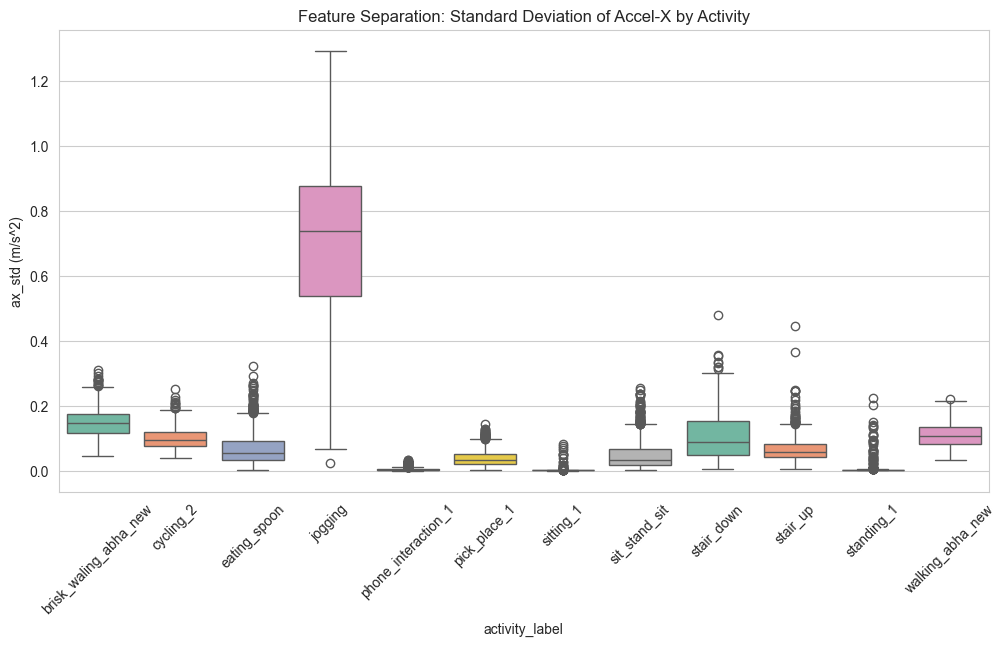

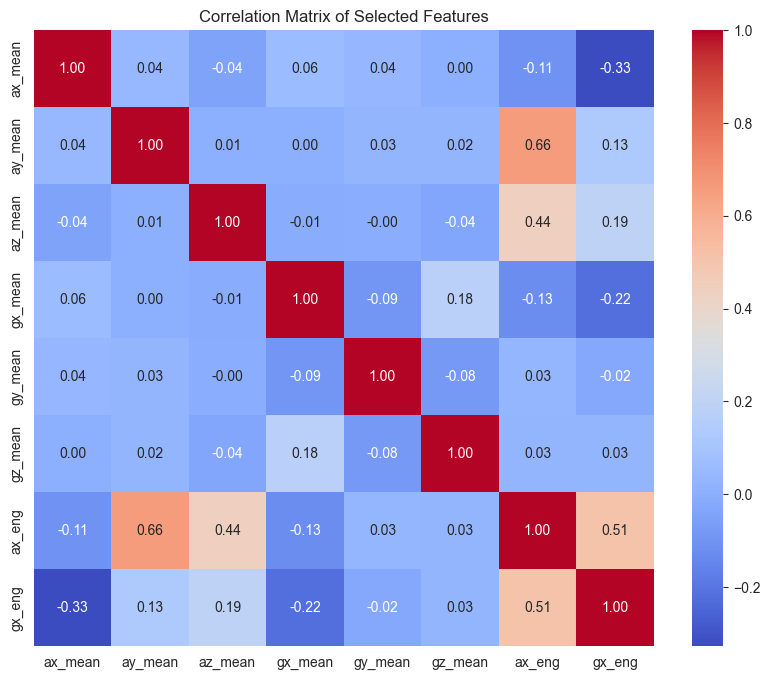

In [20]:
if 'full_dataset' in locals() and not full_dataset.empty:
    
    # Feature Separation Analysis (Boxplot)
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='activity_label', y='ax_std', data=full_dataset, palette='Set2')
    plt.xticks(rotation=45)
    plt.title('Feature Separation: Standard Deviation of Accel-X by Activity')
    plt.ylabel('ax_std (m/s^2)')
    plt.show()

    # Correlation Heatmap (Subset)
    subset_features = ['ax_mean', 'ay_mean', 'az_mean', 'gx_mean', 'gy_mean', 'gz_mean', 'ax_eng', 'gx_eng']
    plt.figure(figsize=(10, 8))
    sns.heatmap(full_dataset[subset_features].corr(), annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Correlation Matrix of Selected Features')
    plt.show()

Dataset Loaded Successfully: (13334, 73)
Columns: ['ax_raw', 'ay_raw', 'az_raw', 'gx_raw', 'gy_raw'] ...


C:\Users\abhap\AppData\Local\Temp\ipykernel_25464\1476148885.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y=y, palette="viridis", order=y.value_counts().index)


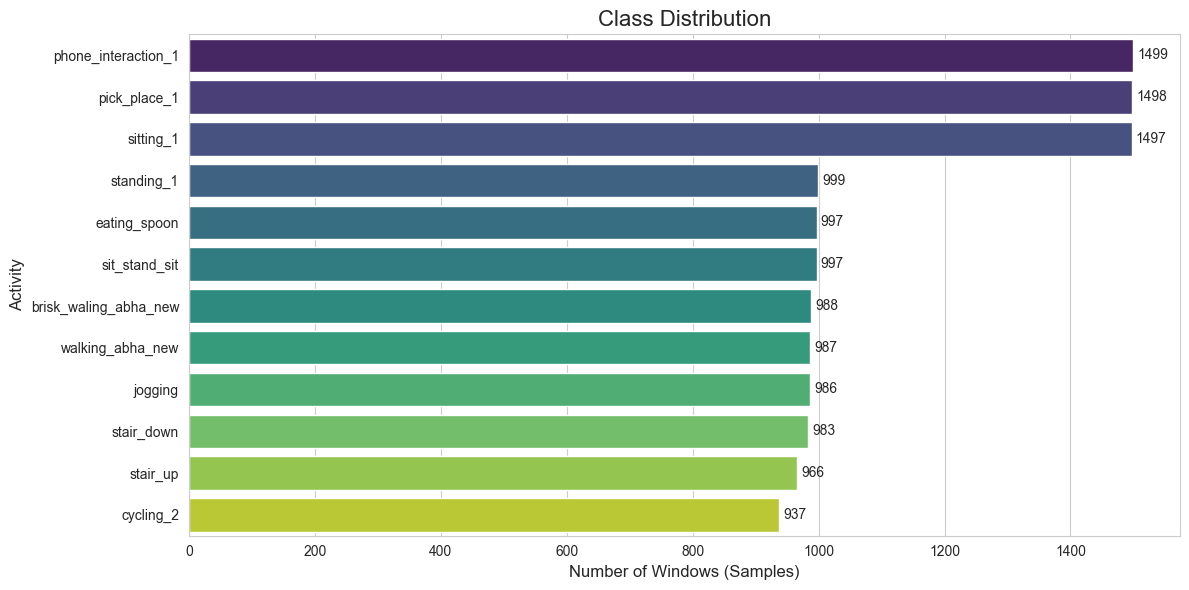

--------------------------------------------------


C:\Users\abhap\AppData\Local\Temp\ipykernel_25464\1476148885.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feat, y='activity_label', palette="tab20", showfliers=False)
C:\Users\abhap\AppData\Local\Temp\ipykernel_25464\1476148885.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feat, y='activity_label', palette="tab20", showfliers=False)
C:\Users\abhap\AppData\Local\Temp\ipykernel_25464\1476148885.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feat, y='activity_label', palette="tab20", showfli

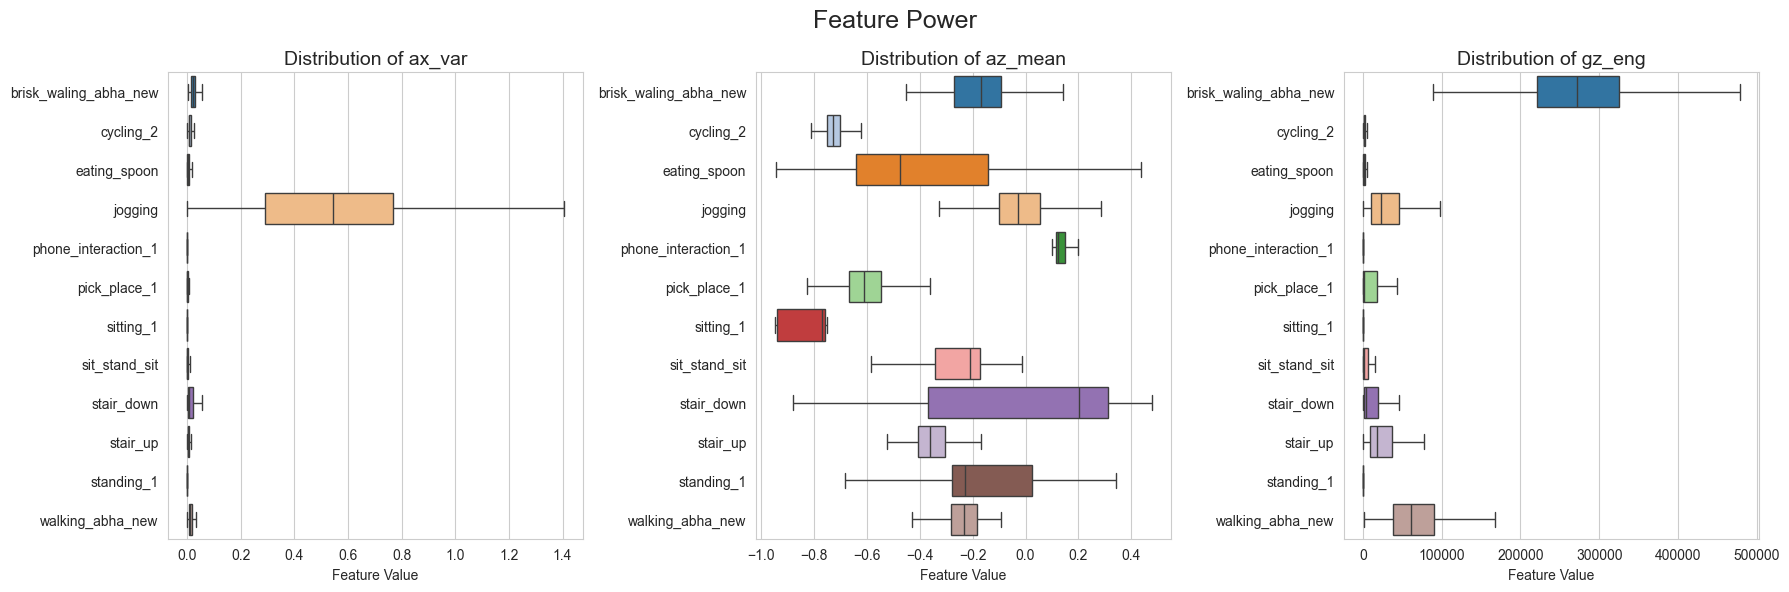

--------------------------------------------------


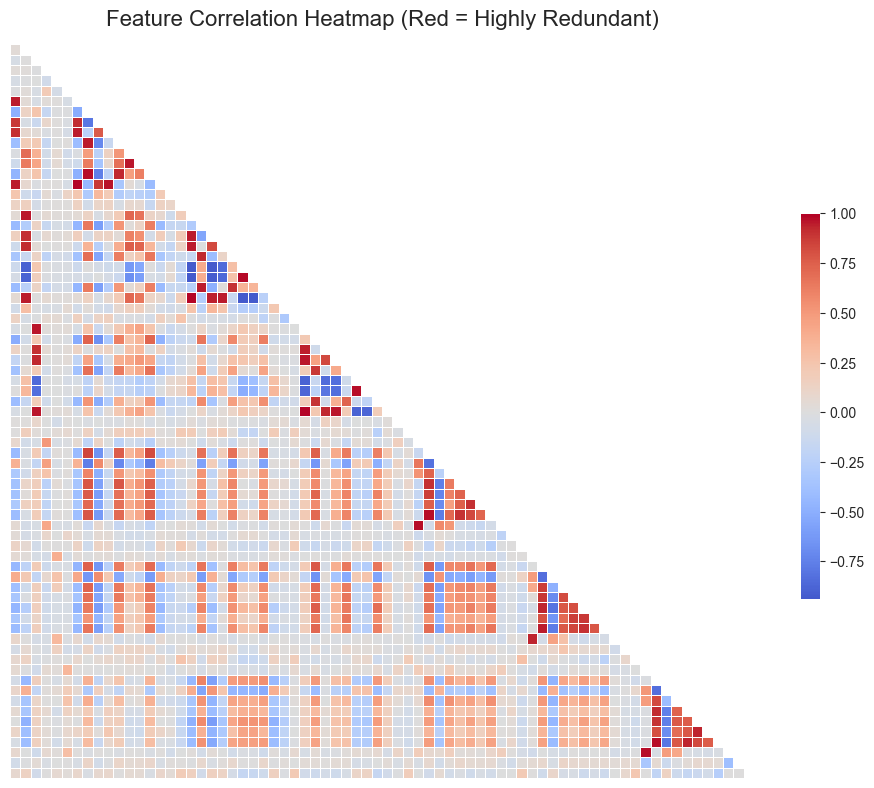

--------------------------------------------------
Running t-SNE on processed features... (This validates your 'calculate_features' function)


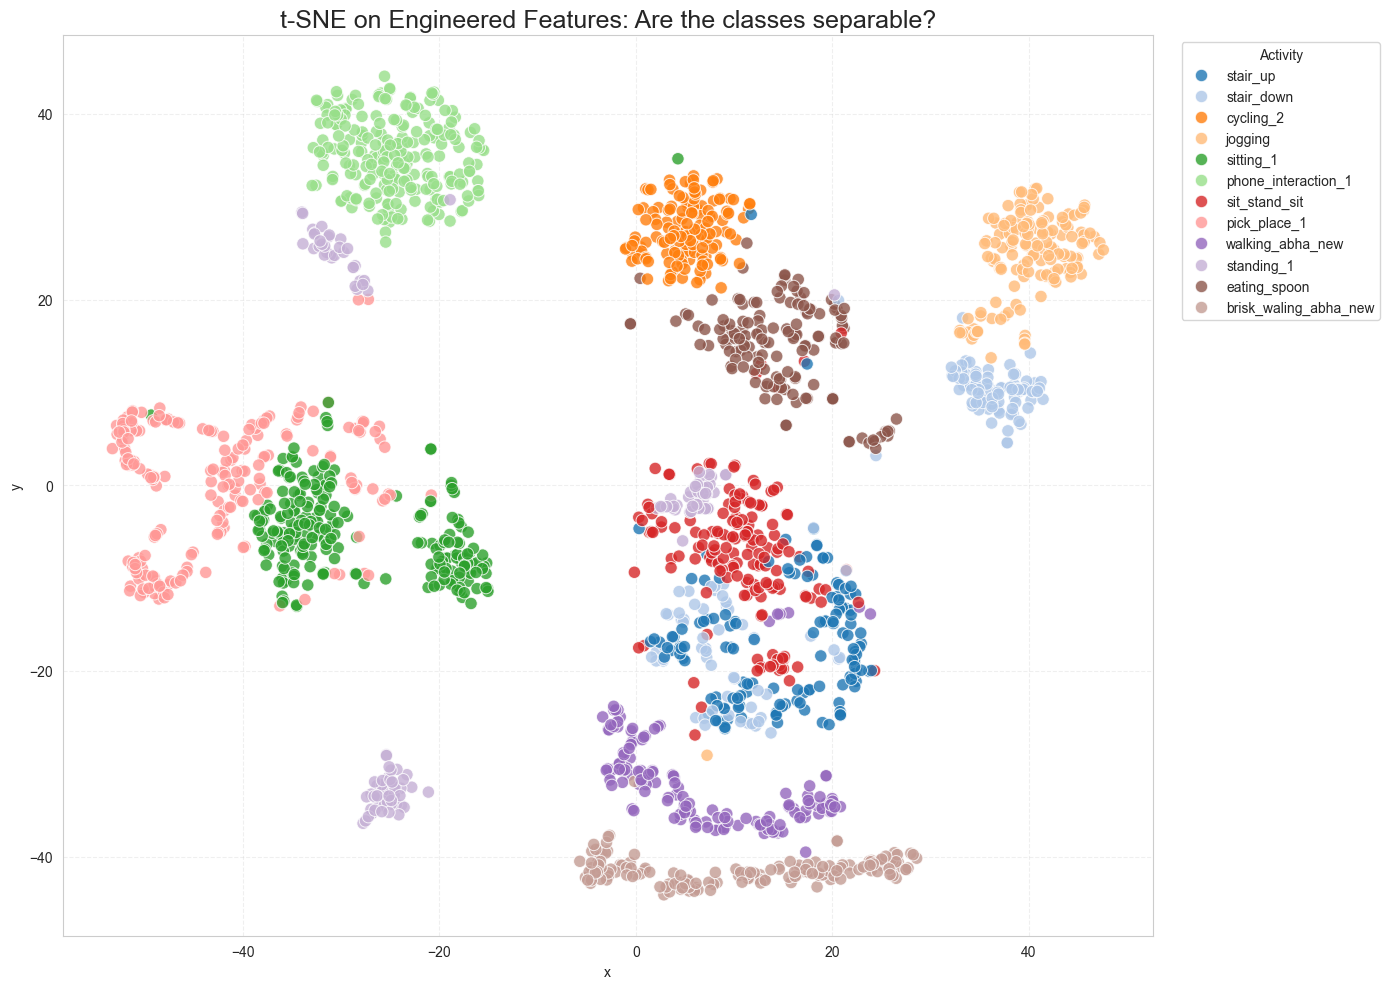

--------------------------------------------------
Calculating Feature Importance...


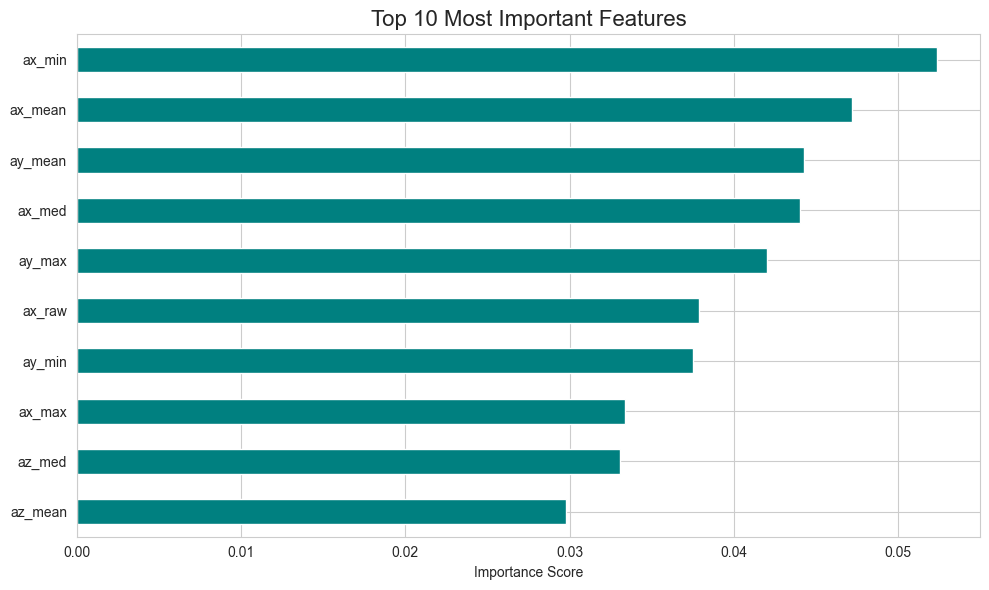

In [21]:
FULL_DATA_PATH = "C:/Users/abhap/OneDrive/Desktop/Edge_AI/27086_AbhaSinghSardar_Assignment1/Activities/raw_activities/full_processed_dataset.csv"

try:
    df = pd.read_csv(FULL_DATA_PATH)
    print(f"Dataset Loaded Successfully: {df.shape}")
    print(f"Columns: {list(df.columns[:5])} ...")
except FileNotFoundError:
    print("Error: File not found. Make sure previous step completed successfully.")
    df = pd.DataFrame() 

if not df.empty:
    df.columns = df.columns.str.strip().str.lower()
    
    X = df.drop(columns=['activity_label'])
    y = df['activity_label']
    
    sns.set_style("whitegrid")

    plt.figure(figsize=(12, 6))
    ax = sns.countplot(y=y, palette="viridis", order=y.value_counts().index)
    plt.title("Class Distribution", fontsize=16)
    plt.xlabel("Number of Windows (Samples)", fontsize=12)
    plt.ylabel("Activity", fontsize=12)
    
    # Add count labels
    for container in ax.containers:
        ax.bar_label(container, padding=3)
    
    plt.tight_layout()
    plt.show()
    print("-" * 50)


    
    key_features = ['ax_var', 'az_mean', 'gz_eng']
    
    available_feats = [f for f in key_features if f in df.columns]
    
    if available_feats:
        plt.figure(figsize=(18, 6))
        for i, feat in enumerate(available_feats):
            plt.subplot(1, 3, i+1)
            sns.boxplot(data=df, x=feat, y='activity_label', palette="tab20", showfliers=False)
            plt.title(f"Distribution of {feat}", fontsize=14)
            plt.xlabel("Feature Value")
            plt.ylabel("") # Hide redundant labels
        
        plt.suptitle("Feature Power", fontsize=18)
        plt.tight_layout()
        plt.show()
    print("-" * 50)



    plt.figure(figsize=(12, 10))
    
    corr_matrix = X.corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        cmap="coolwarm", 
        vmax=1, 
        center=0,
        square=True, 
        linewidths=.5, 
        cbar_kws={"shrink": .5},
        xticklabels=False, 
        yticklabels=False
    )
    plt.title("Feature Correlation Heatmap (Red = Highly Redundant)", fontsize=16)
    plt.show()
    print("-" * 50)



    print("Running t-SNE on processed features... (This validates your 'calculate_features' function)")
    
    if len(df) > 5000:
        df_sample = df.sample(n=2000, random_state=42)
    else:
        df_sample = df.copy()
        
    X_sample = df_sample.drop(columns=['activity_label'])
    y_sample = df_sample['activity_label']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sample)
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_embedded = tsne.fit_transform(X_scaled)
    
    tsne_df = pd.DataFrame(X_embedded, columns=['x', 'y'])
    tsne_df['activity'] = y_sample.values
    
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=tsne_df, 
        x='x', 
        y='y', 
        hue='activity', 
        palette="tab20", 
        s=80, 
        alpha=0.8
    )
    plt.title("t-SNE on Engineered Features: Are the classes separable?", fontsize=18)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Activity")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("-" * 50)


    print("Calculating Feature Importance...")
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    importances = pd.Series(rf.feature_importances_, index=X.columns)
    top_10 = importances.nlargest(10)
    
    plt.figure(figsize=(10, 6))
    top_10.sort_values().plot(kind='barh', color='teal')
    plt.title("Top 10 Most Important Features", fontsize=16)
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.show()

### Model Training

### a. Model Training: Decision Tree

Training Decision Tree...
Model trained and saved.

Accuracy: 0.9704 (97.04%)
Log Loss: 1.0677

--- Classification Report ---
                       precision    recall  f1-score   support

brisk_waling_abha_new       0.99      0.99      0.99       198
            cycling_2       1.00      1.00      1.00       187
         eating_spoon       1.00      0.99      0.99       199
              jogging       0.99      0.98      0.99       197
  phone_interaction_1       1.00      1.00      1.00       300
         pick_place_1       0.99      0.99      0.99       300
        sit_stand_sit       0.94      0.92      0.93       199
            sitting_1       0.99      1.00      1.00       300
           stair_down       0.87      0.87      0.87       197
             stair_up       0.86      0.90      0.88       193
           standing_1       0.99      0.98      0.99       200
     walking_abha_new       0.97      0.98      0.98       197

             accuracy                           0.97 

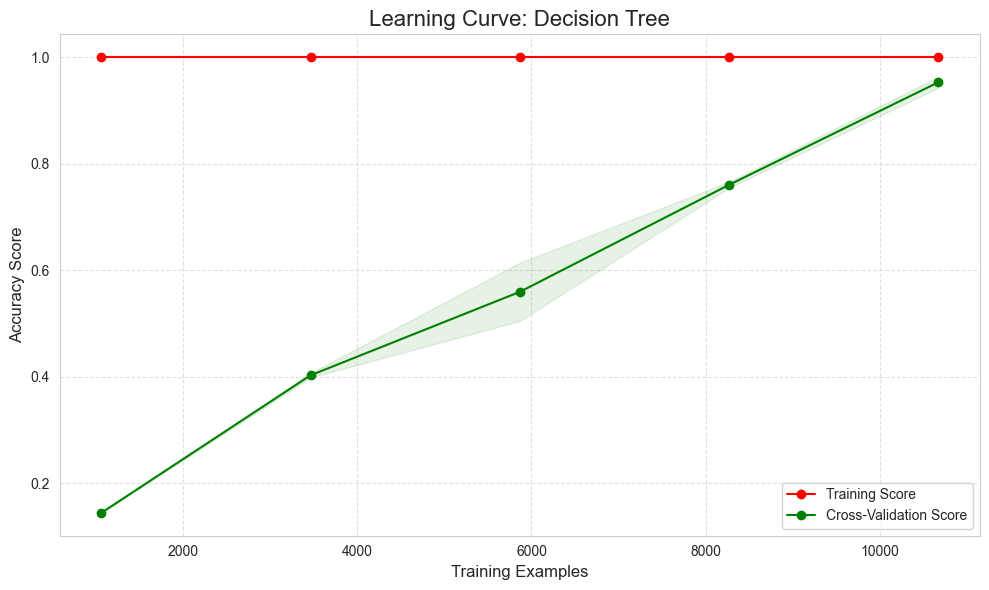

In [22]:
if 'full_dataset' in locals() and not full_dataset.empty:
    X = full_dataset.drop(columns=['activity_label'])
    y = full_dataset['activity_label']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print("Training Decision Tree...")
    clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
    clf.fit(X_train, y_train)

    joblib.dump(clf, "activity_model_dt.pkl")
    print("Model trained and saved.")

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {acc:.4f} ({acc*100:.2f}%)")

    try:
        loss = log_loss(y_test, y_prob)
        print(f"Log Loss: {loss:.4f}")
    except ValueError:
        print("Log Loss skipped.")

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred))

    print("Generating Learning Curve...")
    
    train_sizes, train_scores, test_scores = learning_curve(
        clf, X, y, cv=5, scoring='accuracy', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-Validation Score")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

    plt.title("Learning Curve: Decision Tree", fontsize=16)
    plt.xlabel("Training Examples", fontsize=12)
    plt.ylabel("Accuracy Score", fontsize=12)
    plt.legend(loc="best")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

else:
    print("full_dataset is missing.")

### Evaluation and Visualization


Model Accuracy: 97.04%

Classification Report:
                       precision    recall  f1-score   support

brisk_waling_abha_new       0.99      0.99      0.99       198
            cycling_2       1.00      1.00      1.00       187
         eating_spoon       1.00      0.99      0.99       199
              jogging       0.99      0.98      0.99       197
  phone_interaction_1       1.00      1.00      1.00       300
         pick_place_1       0.99      0.99      0.99       300
        sit_stand_sit       0.94      0.92      0.93       199
            sitting_1       0.99      1.00      1.00       300
           stair_down       0.87      0.87      0.87       197
             stair_up       0.86      0.90      0.88       193
           standing_1       0.99      0.98      0.99       200
     walking_abha_new       0.97      0.98      0.98       197

             accuracy                           0.97      2667
            macro avg       0.97      0.97      0.97      2667
     

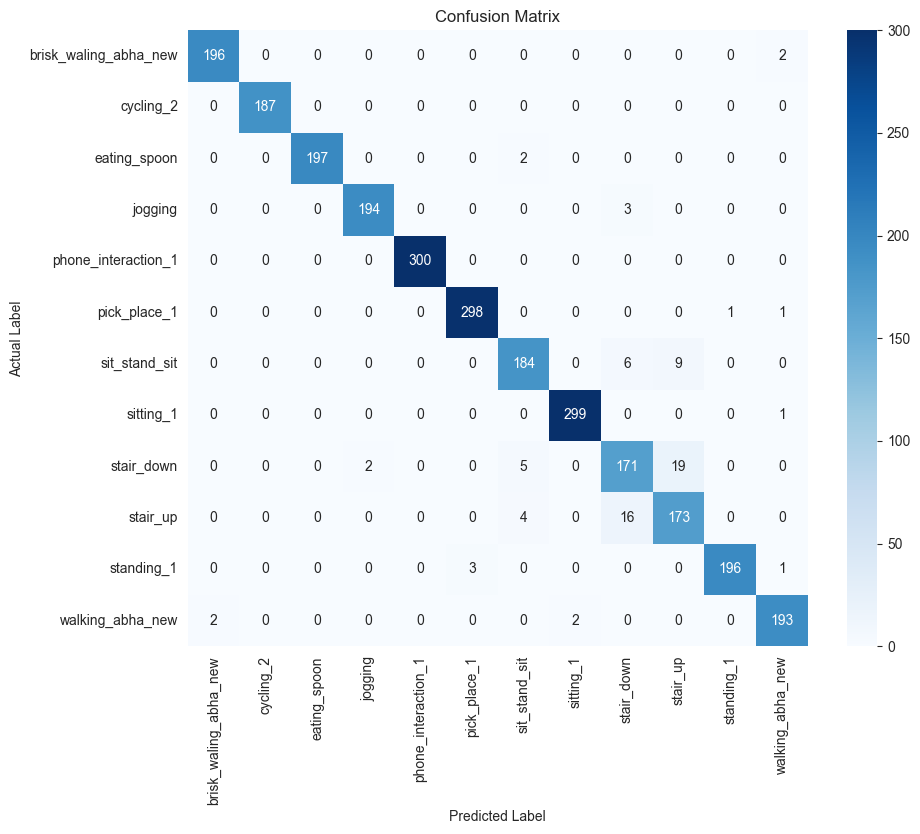

In [23]:
if dataset_list:
    y_pred = clf.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\nModel Accuracy: {acc * 100:.2f}%")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

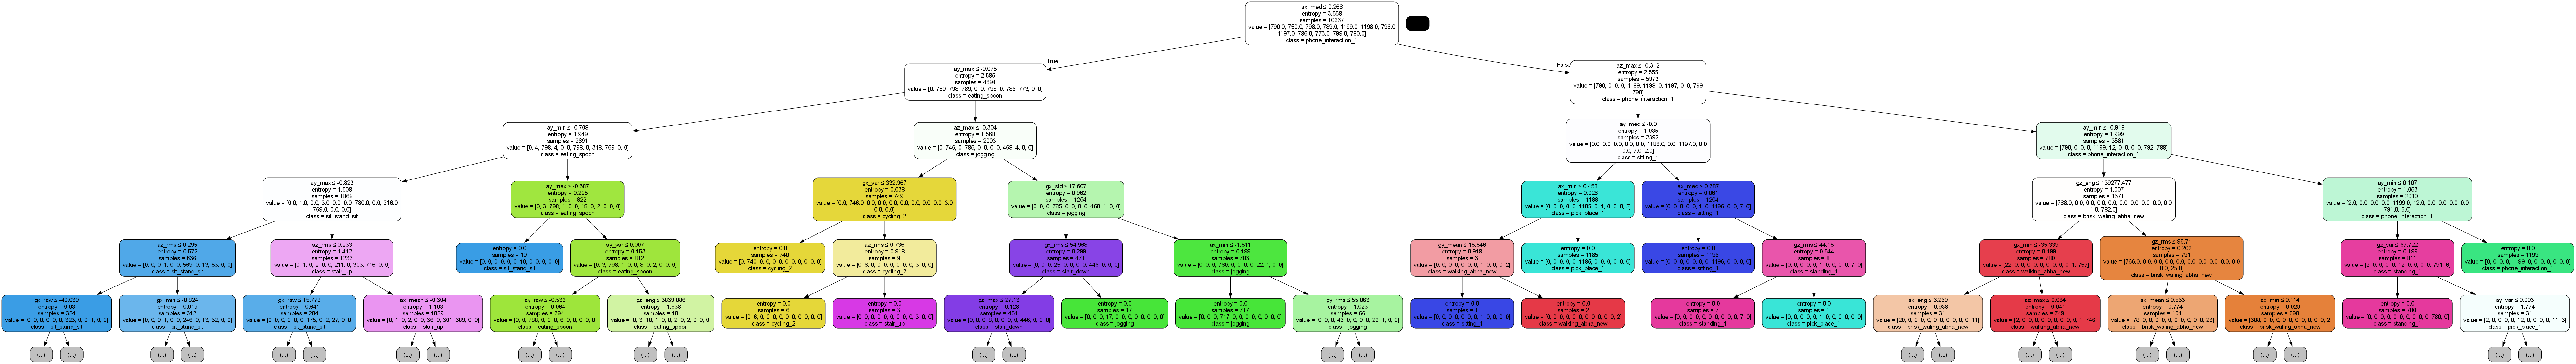

In [24]:
feature_cols = X_train.columns
class_labels = clf.classes_.astype(str) 

dot_data = StringIO()

export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                feature_names=feature_cols,
                class_names=class_labels,
                max_depth=5) 

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())

Image(graph.create_png())

In [25]:
text_representation = tree.export_text(clf)
print(text_representation)

|--- feature_14 <= 0.27
|   |--- feature_20 <= -0.07
|   |   |--- feature_19 <= -0.71
|   |   |   |--- feature_20 <= -0.82
|   |   |   |   |--- feature_33 <= 0.30
|   |   |   |   |   |--- feature_3 <= -40.04
|   |   |   |   |   |   |--- feature_31 <= -0.13
|   |   |   |   |   |   |   |--- class: stair_up
|   |   |   |   |   |   |--- feature_31 >  -0.13
|   |   |   |   |   |   |   |--- class: sit_stand_sit
|   |   |   |   |   |--- feature_3 >  -40.04
|   |   |   |   |   |   |--- class: sit_stand_sit
|   |   |   |   |--- feature_33 >  0.30
|   |   |   |   |   |--- feature_41 <= -0.82
|   |   |   |   |   |   |--- feature_63 <= -9.70
|   |   |   |   |   |   |   |--- feature_6 <= -0.31
|   |   |   |   |   |   |   |   |--- feature_64 <= 29.21
|   |   |   |   |   |   |   |   |   |--- feature_63 <= -13.98
|   |   |   |   |   |   |   |   |   |   |--- feature_23 <= 15.31
|   |   |   |   |   |   |   |   |   |   |   |--- class: stair_down
|   |   |   |   |   |   |   |   |   |   |--- feature_23 >  

In [26]:
model_to_python_dt = m2c.export_to_python(clf)

In [27]:
print(model_to_python_dt)

def score(input):
    if input[14] <= 0.267791748046875:
        if input[20] <= -0.07488999888300896:
            if input[19] <= -0.7078244984149933:
                if input[20] <= -0.8234249949455261:
                    if input[33] <= 0.2951289415359497:
                        if input[3] <= -40.0390625:
                            if input[31] <= -0.13446049764752388:
                                var0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0]
                            else:
                                var0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                        else:
                            var0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]
                    else:
                        if input[41] <= -0.8239744901657104:
                            if input[63] <= -9.70458984375:
                                if input[6] <= -0.31345516443252563:
                                    if input[